# Continuous-Time Derivative Pricing Assignment 2026

This notebook contains the solutions to the assignment tasks. It also includes additional material that goes beyond what is shown on the poster.

All figures used in the poster are stored in the `figs/` folder.


In [1]:
# Necessary imports
import numpy as np
from datetime import datetime
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import matplotlib.colors as mcolors

from cycler import cycler
from tueplots import bundles
from tueplots import axes, fonts, fontsizes
from tueplots.constants.color import palettes, rgb

import pandas as pd
from src.utils import load_svensson_params 

from datetime import datetime

from src.valuation import (
    nelson_siegel_svensson_model,
    zero_to_short,
    idx_of,
    price_express_certificate_one_day,
    price_and_greeks,
    price_and_extended_greeks,
    error_metrics,
)

from src.portfolio_insurance import (
    risk_metrics,
    black_scholes_put,
    evaluate_put_insurance_strategy,
)

from scipy.signal import savgol_filter
import matplotlib.dates as mdates

### Plot styling

In [ ]:
# General style settings
style = bundles.beamer_moml()
plt.rcParams.update(style)

# Adjust font sizes
plt.rcParams['axes.labelsize'] = 16    # x and y labels
plt.rcParams['axes.titlesize'] = 18    # plot titles
plt.rcParams['xtick.labelsize'] = 13   # tick labels
plt.rcParams['ytick.labelsize'] = 13
plt.rcParams['legend.fontsize'] = 13   # match tick sizes
plt.rcParams['font.size'] = 13

# Ensure font alignment
plt.rcParams.update({
    "text.usetex": True,               # Set to False if you don't have a local LaTeX installation
    "font.family": "serif",
    "font.serif": ["Latin Modern Roman"],
})


## Part 1

### III. Product payoff

/var/folders/6v/992p8knd6g5flm6m0p856jlw0000gn/T/ipykernel_83487/3703658265.py:103: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


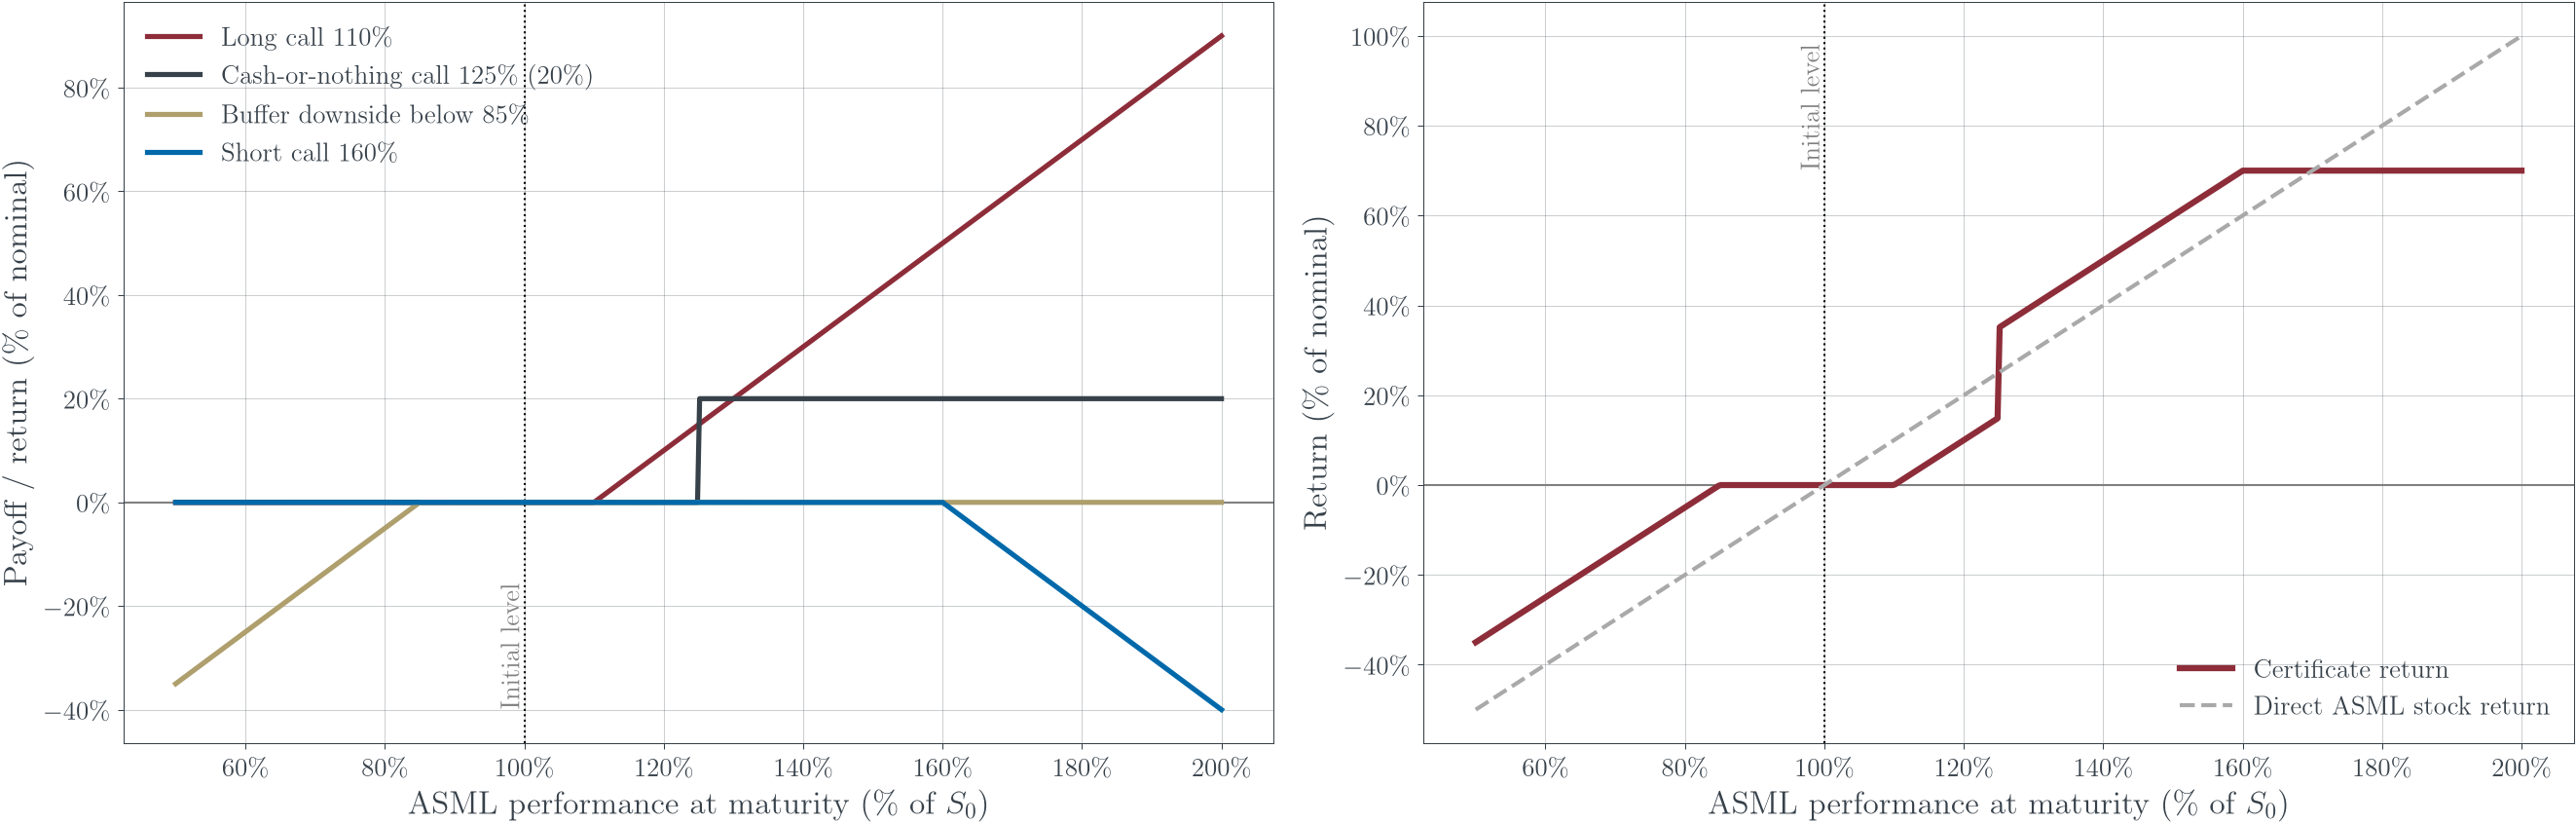

In [3]:
# ASML Growth Buffer Certificate

# Normalized ASML initial level
# S0 = 100 means all strikes are expressed as % of initial ASML price
S0 = 100
x = np.linspace(0.5 * S0, 2.0 * S0, 500)

# Strike / trigger levels
k_call = 1.10 * S0       # long call strike: 110%
k_digi = 1.25 * S0       # digital call trigger: 125%
k_buffer = 0.85 * S0     # downside buffer level: 85%
k_cap = 1.60 * S0        # short call cap: 160%

# Product parameter
digi_pay = 0.20 * S0     # fixed digital payoff: 20% of nominal

# Individual payoff components
vanilla_call = np.maximum(0, x - k_call)
digital_call = np.where(x >= k_digi, digi_pay, 0)
buffer_loss = np.where(x < k_buffer, x - k_buffer, 0)
short_cap_call = -np.maximum(0, x - k_cap)

# Aggregate certificate return before issuance costs
certificate_return = (
    vanilla_call
    + digital_call
    + buffer_loss
    + short_cap_call
)

# Direct ASML stock return
rel = lambda arr: arr / S0
rel_stock = (x - S0) / S0

# Plot
fig, axs = plt.subplots(1, 2, figsize=(18, 6), dpi=150)

# Left plot: individual payoff components
axs[0].axvline(S0, ls=":", color="black", lw=1)
axs[0].axhline(0, color="grey", lw=1)


axs[0].text(
    S0,
    -0.40,
    "Initial level",
    rotation=90,
    va="bottom",
    ha="right",
    color="gray",
)


axs[0].plot(x, rel(vanilla_call), label=r"Long call 110\%", lw=2.5)
axs[0].plot(x, rel(digital_call), label=r"Cash-or-nothing call 125\% (20\%)", lw=2.5)
axs[0].plot(x, rel(buffer_loss), label=r"Buffer downside below 85\%", lw=2.5)
axs[0].plot(x, rel(short_cap_call), label=r"Short call 160\%", lw=2.5)

axs[0].set_xlabel(r"ASML performance at maturity (\% of $S_0$)")
axs[0].set_ylabel(r"Payoff / return (\% of nominal)")
axs[0].xaxis.set_major_formatter(mtick.PercentFormatter(xmax=100))
axs[0].yaxis.set_major_formatter(mtick.PercentFormatter(xmax=1.0))
axs[0].legend(loc="upper left",frameon=False)
axs[0].grid(alpha=0.25)

# Right plot: aggregate certificate return versus direct stock return
axs[1].axvline(S0, ls=":", color="black", lw=1)
axs[1].axhline(0, color="grey", lw=1)

axs[1].text(
    S0,
    0.70,
    "Initial level",
    rotation=90,
    va="bottom",
    ha="right",
    color="gray",
)

axs[1].plot(
    x,
    rel(certificate_return),
    lw=3,
    label="Certificate return",
)

axs[1].plot(
    x,
    rel_stock,
    ls="--",
    lw=2,
    color="darkgrey",
    label="Direct ASML stock return",
)

axs[1].set_xlabel(r"ASML performance at maturity (\% of $S_0$)")
axs[1].set_ylabel(r"Return (\% of nominal)")
axs[1].xaxis.set_major_formatter(mtick.PercentFormatter(xmax=100))
axs[1].yaxis.set_major_formatter(mtick.PercentFormatter(xmax=1.0))
axs[1].legend(loc="lower right",frameon=False)
axs[1].grid(alpha=0.25)

plt.tight_layout()

# Save figure
plt.savefig("figs/part1_payoff.pdf", bbox_inches="tight")

plt.show()

## Part 2

The following code cells deal with data loading, setup, and preprocessing.

The underlying stock and certificate data are pulled from [Onvista](https://www.onvista.de/derivate/Optionsscheine), while the Svensson parameter data is retrieved directly from the [Deutsche Bundesbank](https://www.bundesbank.de/en/statistics/money-and-capital-markets/interest-rates-and-yields/daily-term-structure-on-listed-federal-securities-651570).

In [4]:
# Paths for ASML underlying, traded certificate, and Svensson parameter data
UNDERLYING_DATA_PATH = "./data/asml.csv"
CERTIFICATE_DATA_PATH = "./data/asml_express.csv"
SVENSSON_PARAMS_PATH = "./data/svensson_params/"

# Valuation window
START_DATE_VALUATION = "2025-12-15"
END_DATE_VALUATION = "2026-06-15"

# Constants
TRADING_DAYS = 252
VOL_WINDOW = 252

In [5]:
# Define product parameters for the ASML Express Certificate
PRODUCT_PARAMS = {
    "S_START": 682.50,
    "NOMINAL": 1000.0,
    "BARRIER": 443.625,
    "BASIS_PRICE": 682.50,
    "MAX_AMOUNT": 1358.50,
    "SHARES": 1.465201,

    "LEVELS": (
        682.50,     # 100% of inital reference price
        648.375,    # 95% of initial reference price
    ),

    "OBS_DATES": (
        datetime(2026, 6, 24),
        datetime(2027, 6, 24),
    ),

    "EARLY_REDEMPTION_DATES": (
        datetime(2026, 7, 1),
        datetime(2027, 7, 1),
    ),

    "EARLY_REDEMPTION_AMOUNTS": (
        1119.50,
        1239.00,
    ),

    "FINAL_OBS_DATE": datetime(2028, 6, 26),
    "MATURITY": datetime(2028, 7, 3),

    "TRADING_DAYS": 252,
    # Approximate trading-day fraction per calendar day
    "STEPS_PER_DAY": 252 / 365,
}

In [6]:
# Load ASML underlying data and normalize the German-formatted price columns
asml_df = pd.read_csv(UNDERLYING_DATA_PATH, delimiter=";")

# Convert German number format to floats
price_cols = ["Eröffnung", "Hoch", "Tief", "Schluss"]

for col in price_cols:
    asml_df[col] = (
        asml_df[col]
        .astype(str)
        .str.replace(".", "", regex=False)
        .str.replace(",", ".", regex=False)
        .replace({"-": np.nan})
        .astype(float)
    )

# Parse and sort date column
asml_df["Datum"] = pd.to_datetime(asml_df["Datum"], dayfirst=True)
asml_df = asml_df.sort_values("Datum").reset_index(drop=True)

# Calculate log returns and one-year rolling historical volatility
asml_df["log_return"] = np.log(asml_df["Schluss"] / asml_df["Schluss"].shift(1))
asml_df["hist_volatility"] = (
    asml_df["log_return"]
    .rolling(window=VOL_WINDOW)
    .std()
    * np.sqrt(TRADING_DAYS)
)

asml_df = asml_df.rename(columns={"Schluss": "underlying_price"})

In [7]:
# Load Svensson parameter data
svensson_df = load_svensson_params(SVENSSON_PARAMS_PATH)

# Keep only dates relevant for the available ASML data
latest_date = asml_df["Datum"].max()
cutoff_date = latest_date - pd.Timedelta(days=365 * 3)
svensson_df = svensson_df[svensson_df["Datum"] >= cutoff_date].copy()

# Merge latest available Svensson parameters into ASML data
asml_df = pd.merge(
    asml_df,
    svensson_df,
    on="Datum",
    how="left"
)

In [8]:
# Load traded Express Plus Certificate data and normalize the quoted prices
certificate_df = pd.read_csv(CERTIFICATE_DATA_PATH, delimiter=";")

price_cols = ["Eröffnung", "Hoch", "Tief", "Schluss"]

for col in price_cols:
    certificate_df[col] = (
        certificate_df[col]
        .astype(str)
        .str.replace(".", "", regex=False)
        .str.replace(",", ".", regex=False)
        .replace({"-": np.nan})
        .astype(float)
    )

certificate_df["Datum"] = pd.to_datetime(certificate_df["Datum"], dayfirst=True)
certificate_df = certificate_df.sort_values("Datum").reset_index(drop=True)

certificate_df = certificate_df.rename(columns={"Schluss": "certificate_quote"})

# Convert quoted levels to EUR only when the source file stores percentage-of-nominal values.
if certificate_df["certificate_quote"].median() < 200:
    certificate_df["certificate_price_eur"] = (
        certificate_df["certificate_quote"] / 100 * PRODUCT_PARAMS["NOMINAL"]
    )
else:
    certificate_df["certificate_price_eur"] = certificate_df["certificate_quote"]

display(certificate_df[["Datum", "certificate_quote", "certificate_price_eur"]].head())
display(certificate_df[["Datum", "certificate_quote", "certificate_price_eur"]].tail())

,Datum,certificate_quote,certificate_price_eur
0,2025-07-01,975.56,975.56
1,2025-07-02,980.23,980.23
2,2025-07-03,979.43,979.43
3,2025-07-04,983.90,983.90
4,2025-07-07,975.00,975.00


,Datum,certificate_quote,certificate_price_eur
237,2026-06-09,1101.46,1101.46
238,2026-06-10,1101.52,1101.52
239,2026-06-11,1107.28,1107.28
240,2026-06-12,1101.77,1101.77
241,2026-06-15,1085.15,1085.15


In [9]:
# Filter ASML and certificate data to valuation window
asml_val = asml_df[
    (asml_df["Datum"] >= START_DATE_VALUATION)
    & (asml_df["Datum"] <= END_DATE_VALUATION)
].copy()

certificate_val = certificate_df[
    (certificate_df["Datum"] >= START_DATE_VALUATION)
    & (certificate_df["Datum"] <= END_DATE_VALUATION)
].copy()

# Keep only relevant columns
asml_val = asml_val[
    [
        "Datum",
        "underlying_price",
        "log_return",
        "hist_volatility",
        "beta0",
        "beta1",
        "beta2",
        "beta3",
        "tau1",
        "tau2",
    ]
]

certificate_val = certificate_val[
    [
        "Datum",
        "certificate_quote",
        "certificate_price_eur",
    ]
]

# Merge underlying, volatility, interest-rate parameters, and certificate prices
valuation_df = certificate_val.merge(asml_val, on="Datum", how="inner")

print("Start date:", valuation_df["Datum"].min().date())
print("End date:", valuation_df["Datum"].max().date())
print("Matched trading days:", len(valuation_df))
print("Missing volatility values:", valuation_df["hist_volatility"].isna().sum())
print(
    "Missing Svensson rows:",
    valuation_df[["beta0", "beta1", "beta2", "beta3", "tau1", "tau2"]]
    .isna()
    .any(axis=1)
    .sum()
)

# Sanity checks for complete valuation inputs
assert len(valuation_df) >= 100
assert valuation_df["hist_volatility"].notna().all()
assert valuation_df[["beta0", "beta1", "beta2", "beta3", "tau1", "tau2"]].notna().all().all()

valuation_df.head()

Start date: 2025-12-15
End date: 2026-06-15
Matched trading days: 123
Missing volatility values: 0
Missing Svensson rows: 0


,Datum,certificate_quote,certificate_price_eur,underlying_price,log_return,hist_volatility,beta0,beta1,beta2,beta3,tau1,tau2
0,2025-12-15,1055.90,1055.90,931.0,0.006141,0.370803,3.04078,-1.07659,-28.00579,29.79871,6.53932,7.01400
1,2025-12-16,1036.68,1036.68,908.6,-0.024354,0.369647,3.04396,-1.09201,-27.96620,29.79781,6.52465,7.00377
2,2025-12-17,1020.71,1020.71,874.0,-0.038825,0.371714,3.22756,-1.27380,-27.99328,29.26908,6.04106,6.45765
3,2025-12-18,1045.90,1045.90,892.7,0.021170,0.372237,3.21586,-1.25945,-27.96469,29.26939,6.01899,6.45084
4,2025-12-19,1036.50,1036.50,901.6,0.009920,0.372298,3.33618,-1.37535,-28.09423,29.27057,5.95697,6.36344


### V. Valuation

The following code cells contain the implementation for Task V, Valuation.

In [10]:
# Initialize lists for daily model prices and their corresponding valuation dates
daily_prices = []
valuation_dates = []

# Value the certificate separately on each trading day in the valuation window
for _, row in valuation_df.iterrows():
    # Extract the current valuation date, underlying price, and volatility estimate
    val_date = row["Datum"].to_pydatetime()
    spot = row["underlying_price"]
    sigma = row["hist_volatility"]

    # Extract the Nelson-Siegel-Svensson parameters observed on the valuation date
    b0, b1, b2, b3, t1, t2 = row[
        ["beta0", "beta1", "beta2", "beta3", "tau1", "tau2"]
    ]

    # Determine the number of remaining trading days until product maturity
    n_steps = idx_of(PRODUCT_PARAMS["MATURITY"], val_date, PRODUCT_PARAMS)

    # Construct year-fraction maturities for all remaining trading days
    horizons = np.arange(1, n_steps + 1) / PRODUCT_PARAMS["TRADING_DAYS"]

    # Calculate zero-coupon rates for the remaining maturities using the NSS yield curve
    R_zero = nelson_siegel_svensson_model(
        horizons,
        b0,
        b1,
        b2,
        b3,
        t1,
        t2,
    )

    # Convert zero-coupon rates into daily short rates for the pricing simulation
    r_vec = zero_to_short(
        R_zero,
        1 / PRODUCT_PARAMS["TRADING_DAYS"],
    )

    # Calculate the model value of the express certificate on the current valuation date
    price = price_express_certificate_one_day(
        spot=spot,
        sigma=sigma,
        val_date=val_date,
        r_vec=r_vec,
        params=PRODUCT_PARAMS,
    )

    # Store the calculated model price and its valuation date
    daily_prices.append(price)
    valuation_dates.append(row["Datum"])

# Combine the daily model values into a date-indexed DataFrame
model_prices_df = pd.DataFrame(
    {"model_price": daily_prices},
    index=valuation_dates,
)


In [11]:
# Merge daily model prices with the corresponding market and input data
valuation_results = valuation_df.merge(
    model_prices_df,
    left_on="Datum",
    right_index=True,
    how="inner",
)

# Display the main valuation inputs and model-versus-market prices
valuation_results[
    [
        "Datum",
        "underlying_price",
        "certificate_price_eur",
        "model_price",
        "hist_volatility",
    ]
].head()

,Datum,underlying_price,certificate_price_eur,model_price,hist_volatility
0,2025-12-15,931.0,1055.90,1087.170080,0.370803
1,2025-12-16,908.6,1036.68,1086.833238,0.369647
2,2025-12-17,874.0,1020.71,1076.325098,0.371714
3,2025-12-18,892.7,1045.90,1080.715685,0.372237
4,2025-12-19,901.6,1036.50,1084.786931,0.372298


/var/folders/6v/992p8knd6g5flm6m0p856jlw0000gn/T/ipykernel_83487/439302073.py:44: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


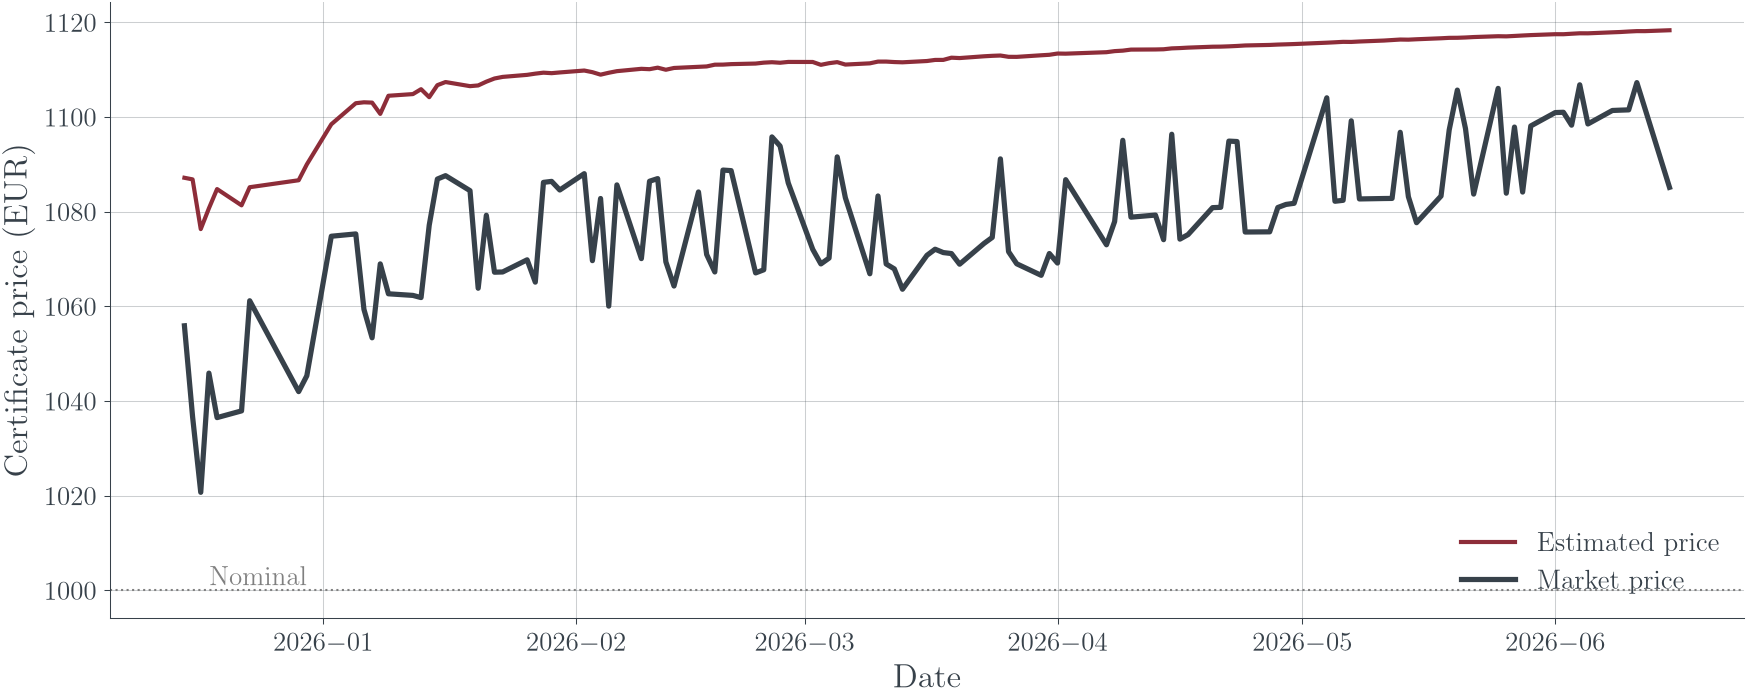

In [12]:
# Plot daily model values against observed certificate prices
fig, ax = plt.subplots(figsize=(12, 5), dpi=150)

ax.plot(
    valuation_results["Datum"],
    valuation_results["model_price"],
    label="Estimated price",
    lw=2,
)

ax.plot(
    valuation_results["Datum"],
    valuation_results["certificate_price_eur"],
    label="Market price",
    lw=2.5,
)

# Add the certificate's nominal value as a reference level
ax.axhline(
    PRODUCT_PARAMS["NOMINAL"],
    ls=":",
    color="gray",
    lw=1,
)

ax.text(
    valuation_results["Datum"].iloc[8],
    PRODUCT_PARAMS["NOMINAL"],
    "Nominal",
    va="bottom",
    ha="right",
    color="gray",
)

ax.set_ylabel("Certificate price (EUR)")
ax.set_xlabel("Date")
ax.legend(loc="lower right", frameon=False)
ax.grid(alpha=0.25)

# Remove unnecessary borders for a cleaner presentation
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.tight_layout()

# Save figure
plt.savefig("figs/part2_valuation.pdf", bbox_inches="tight")

plt.show()

The binomial tree uses rolling historical volatility as model input, following the course guidance for the up- and down-factors. Therefore, the model price is not expected to match the observed market price exactly, since traded certificates are priced using market-implied volatility, issuer margins, funding costs, and supply-demand effects.

In [13]:
# Error metrics
metrics = error_metrics(
    valuation_results["model_price"],
    valuation_results["certificate_price_eur"],
)

metrics_df = pd.Series(metrics).to_frame("Error")
metrics_df

,Error
ME,32.096725
MAE,32.096725
RMSE,33.885315
MPE,2.990365
90%-|e|,44.197382
R²,0.539915


### VI. Sensitivity analysis

The following code cells contain the implementation for Task VI, Sensitivity analysis.

In [14]:
# Use the most recent observation as the sensitivity-analysis snapshot
snap_row = valuation_df.iloc[-1]

snap_date = snap_row["Datum"].to_pydatetime()
sigma = snap_row["hist_volatility"]

# Extract the yield-curve parameters observed on the snapshot date
b0, b1, b2, b3, t1, t2 = snap_row[
    ["beta0", "beta1", "beta2", "beta3", "tau1", "tau2"]
]

# Construct the remaining term structure of daily interest rates
n_steps = idx_of(PRODUCT_PARAMS["MATURITY"], snap_date, PRODUCT_PARAMS)
horizons = np.arange(1, n_steps + 1) / PRODUCT_PARAMS["TRADING_DAYS"]

R_zero = nelson_siegel_svensson_model(
    horizons,
    b0,
    b1,
    b2,
    b3,
    t1,
    t2,
)

r_vec = zero_to_short(
    R_zero,
    1 / PRODUCT_PARAMS["TRADING_DAYS"],
)

# Evaluate the product over a broad but economically sensible range of spot prices
spot_grid = np.linspace(
    0.50 * PRODUCT_PARAMS["S_START"],
    1.40 * PRODUCT_PARAMS["S_START"],
    180,
)

greeks_spot_rows = []

# Reprice the certificate and estimate its Greeks at each hypothetical spot level
for spot in spot_grid:
    price, delta, gamma, vega = price_and_greeks(
        spot=spot,
        sigma=sigma,
        val_date=snap_date,
        r_vec=r_vec,
        params=PRODUCT_PARAMS,
        spot_bump_pct=0.01,
        vega_bump=0.005,
    )

    greeks_spot_rows.append(
        {
            "spot": spot,
            "price": price,
            "delta": delta,
            "gamma": gamma,
            "vega": vega,
        }
    )

# Spot-based sensitivity analysis at the selected snapshot date
greeks_spot_df = pd.DataFrame(greeks_spot_rows)

/var/folders/6v/992p8knd6g5flm6m0p856jlw0000gn/T/ipykernel_83487/3670703479.py:51: UserWarning: The figure layout has changed to tight
  plt.tight_layout(rect=[0, 0.03, 1, 1])


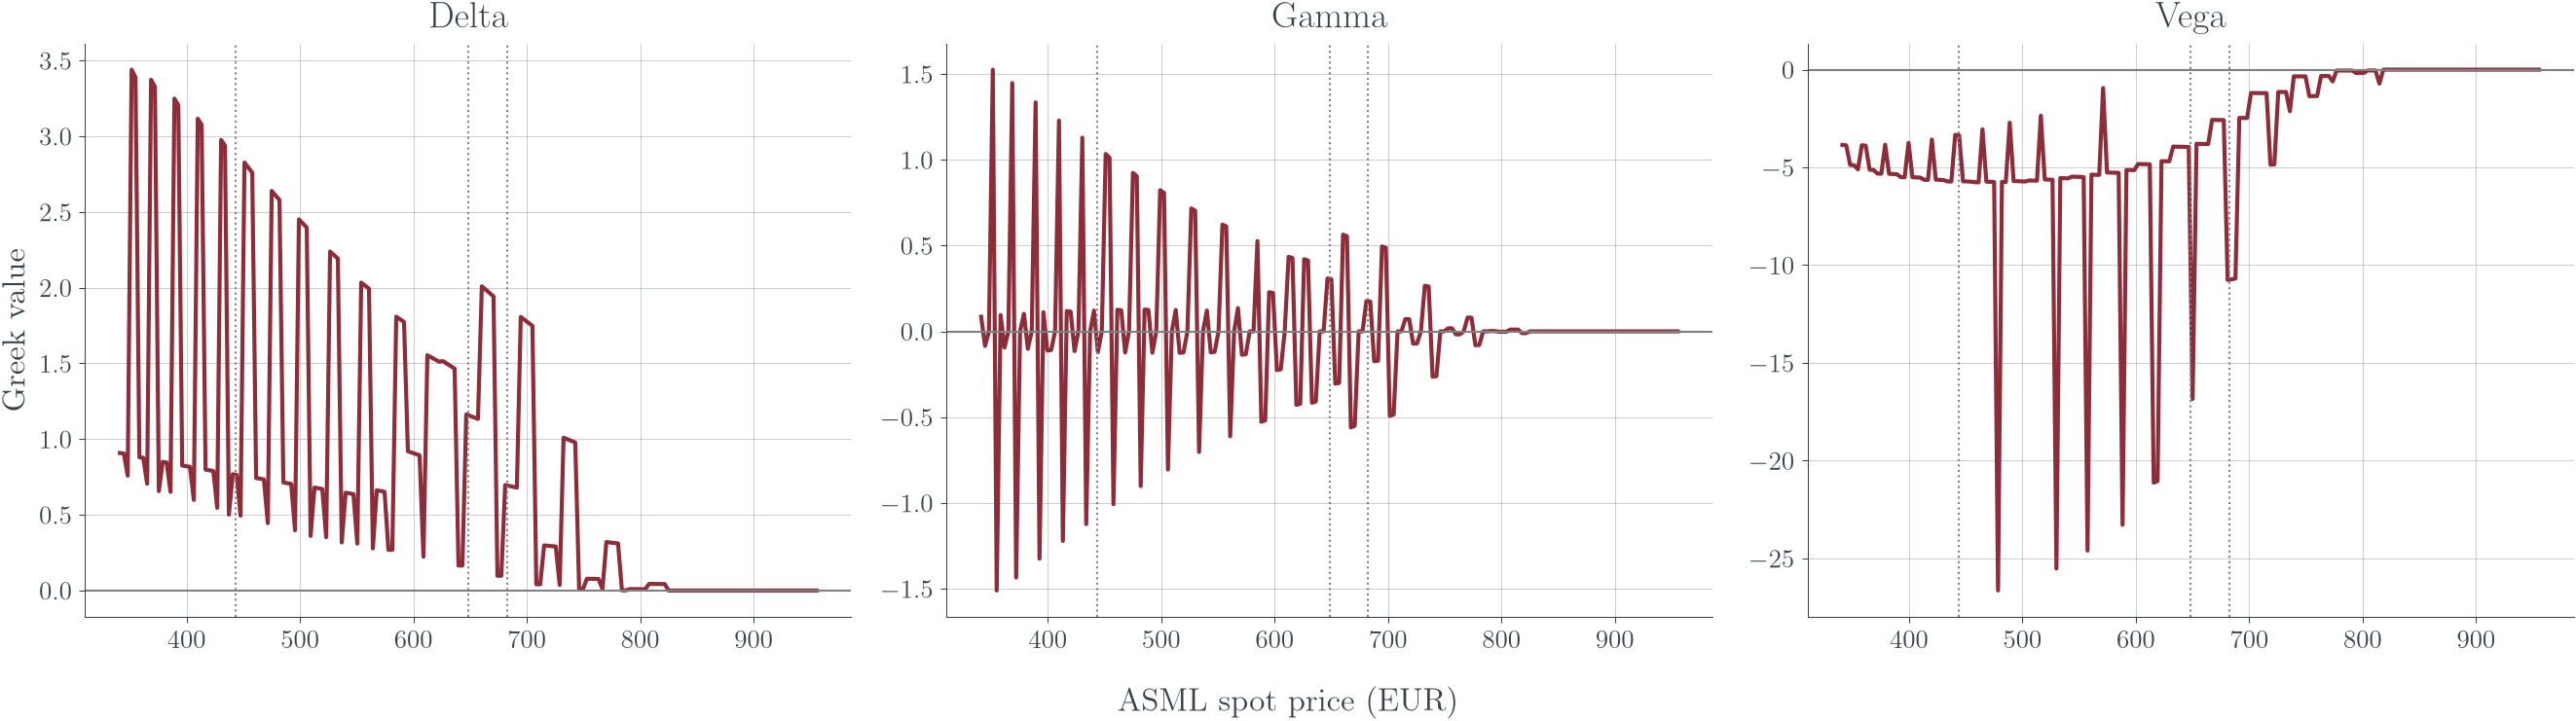

In [15]:
# Plot the raw, unsmoothed Greeks
fig, axes = plt.subplots(1, 3, figsize=(18, 5), dpi=150)

greek_specs = [
    ("delta", "Delta"),
    ("gamma", "Gamma"),
    ("vega", "Vega"),
]

# Contractual ASML levels
thresholds = [
    PRODUCT_PARAMS["BARRIER"],
    PRODUCT_PARAMS["LEVELS"][1],
    PRODUCT_PARAMS["LEVELS"][0],
]

for ax, (column, title) in zip(axes, greek_specs):
    ax.plot(
        greeks_spot_df["spot"],
        greeks_spot_df[column],
        lw=2,
    )

    ax.axhline(0, color="gray", lw=1)

    for level in thresholds:
        ax.axvline(
            level,
            ls=":",
            color="gray",
            lw=1,
        )

    ax.set_title(title, pad=8)
    ax.grid(alpha=0.25)
    ax.tick_params(axis="both")

    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

axes[0].set_ylabel("Greek value")

fig.text(
    0.5,
    -0.01,
    "ASML spot price (EUR)",
    ha="center",
    fontsize=16,
)

plt.tight_layout(rect=[0, 0.03, 1, 1])

plt.show()

Smooth the numerically estimated Greeks with a Savitzky-Golay filter for visualization.

In [16]:
# Define window length and polynomial order for the Savitzky-Golay filter
window_length = 51
polyorder = 3

greeks_spot_df["delta_smooth"] = savgol_filter(
    greeks_spot_df["delta"],
    window_length=window_length,
    polyorder=polyorder,
)

greeks_spot_df["gamma_smooth"] = savgol_filter(
    greeks_spot_df["gamma"],
    window_length=window_length,
    polyorder=polyorder,
)

greeks_spot_df["vega_smooth"] = savgol_filter(
    greeks_spot_df["vega"],
    window_length=window_length,
    polyorder=polyorder,
)

/var/folders/6v/992p8knd6g5flm6m0p856jlw0000gn/T/ipykernel_83487/2438729185.py:55: UserWarning: The figure layout has changed to tight
  plt.tight_layout(rect=[0, 0.03, 1, 1])


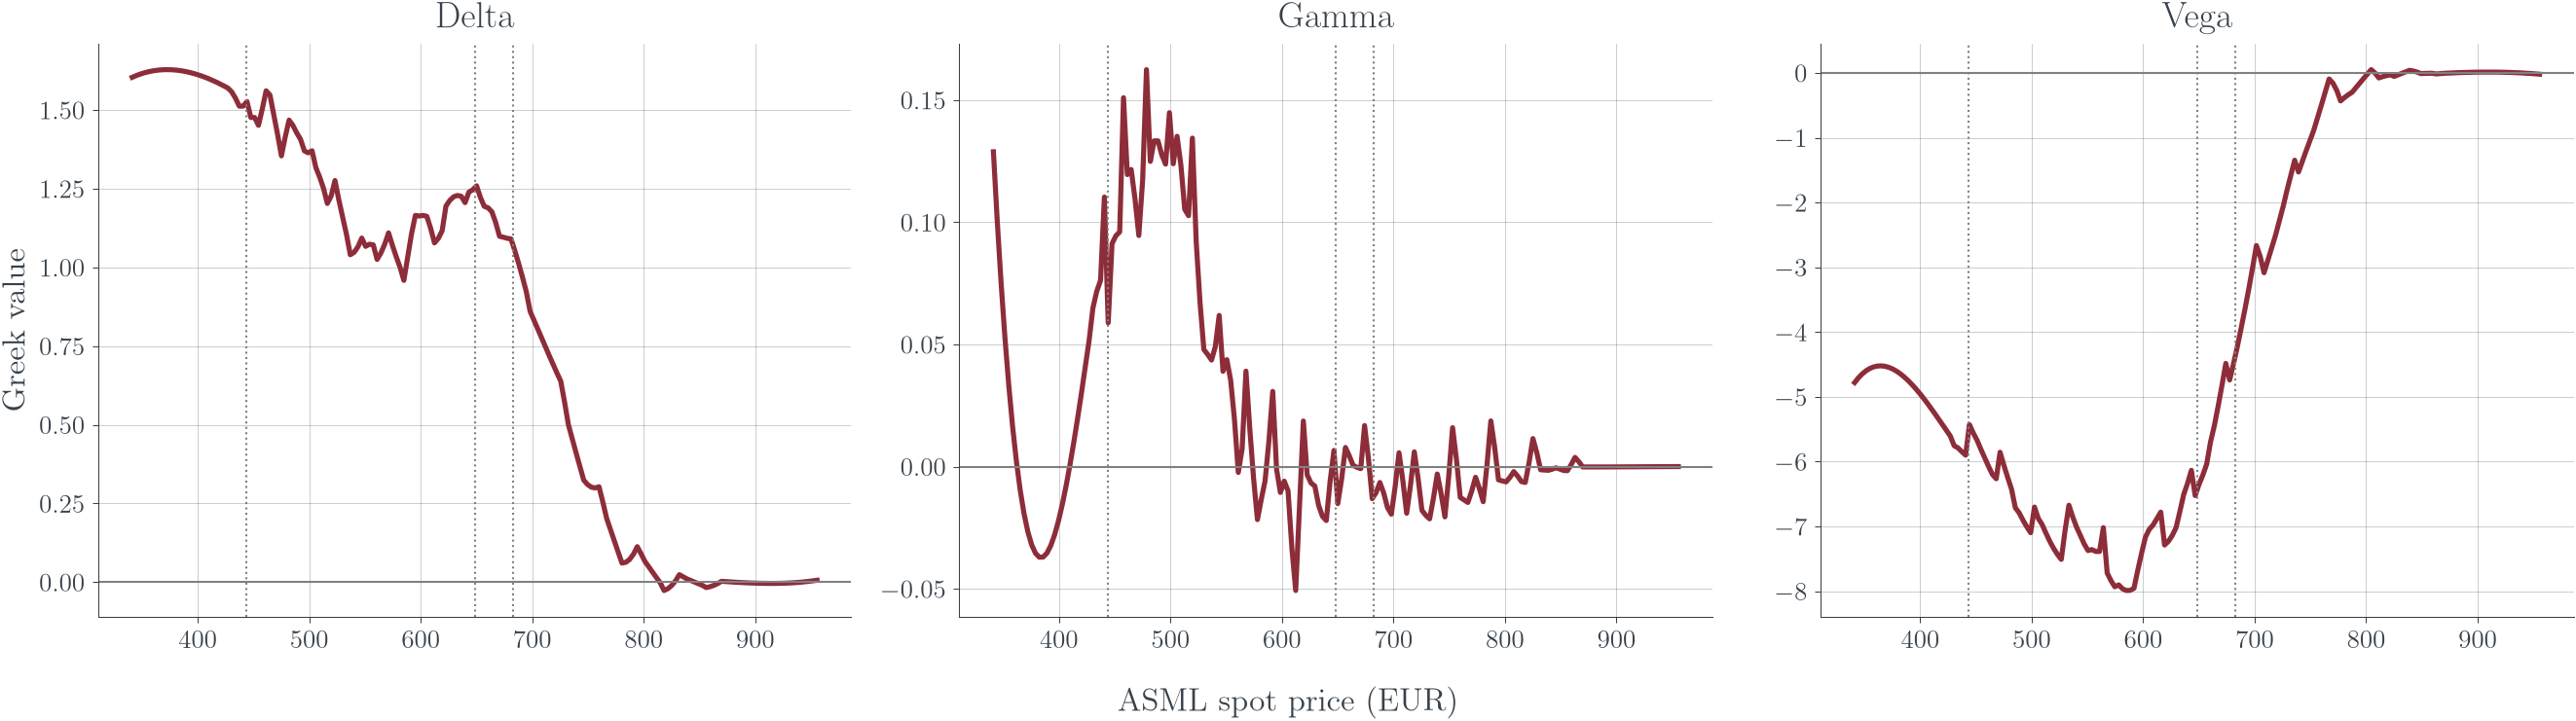

In [17]:
# Plot the smoothed Delta, Gamma, and Vega curves side by side
fig, axes = plt.subplots(1, 3, figsize=(18, 5), dpi=150)

greek_specs = [
    ("delta_smooth", "Delta"),
    ("gamma_smooth", "Gamma"),
    ("vega_smooth", "Vega"),
]

# Contractual spot levels at which the product's payoff behavior may change
thresholds = {
    "Barrier": PRODUCT_PARAMS["BARRIER"],
    "2nd autocall": PRODUCT_PARAMS["LEVELS"][1],
    "1st autocall": PRODUCT_PARAMS["LEVELS"][0],
}

# Apply the same formatting and reference levels to each Greek
for ax, (col, title) in zip(axes, greek_specs):
    ax.plot(
        greeks_spot_df["spot"],
        greeks_spot_df[col],
        lw=2.5,
    )

    ax.axhline(0, color="gray", lw=1)

    # Mark the barrier and autocall levels to support interpretation of sensitivity changes
    for _, level in thresholds.items():
        ax.axvline(
            level,
            ls=":",
            color="gray",
            lw=1,
        )

    ax.set_title(title, pad=8)
    ax.grid(alpha=0.25)

    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

    ax.tick_params(axis="both")

axes[0].set_ylabel("Greek value")

# Add one shared x-axis label for all three panels
fig.text(
    0.5,
    -0.01,
    "ASML spot price (EUR)",
    ha="center",
    fontsize=16,
)

plt.tight_layout(rect=[0, 0.03, 1, 1])

# Save figure
plt.savefig("figs/part2_greeks.pdf", bbox_inches="tight")

plt.show()

Extending the Sensitivity anlysis, to also include Theta and Rho (not used for the poster).

In [18]:
# Calculate the full set of price sensitivities across the spot-price range
extended_greeks_spot_rows = []

for spot in spot_grid:
    price, delta, gamma, vega, rho, theta = price_and_extended_greeks(
        spot=spot,
        sigma=sigma,
        val_date=snap_date,
        r_vec=r_vec,
        params=PRODUCT_PARAMS,
        spot_bump_pct=0.01,
        vega_bump=0.005,
        rho_bump=0.0001,
    )

    extended_greeks_spot_rows.append(
        {
            "spot": spot,
            "price": price,
            "delta": delta,
            "gamma": gamma,
            "vega": vega,
            "rho": rho,
            "theta": theta,
        }
    )

extended_greeks_spot_df = pd.DataFrame(extended_greeks_spot_rows)

extended_greeks_spot_df[
    ["price", "delta", "gamma", "vega", "rho", "theta"]
].describe()

,price,delta,gamma,vega,rho,theta
count,180.000000,180.000000,180.000000,180.000000,180.000000,180.000000
mean,967.042535,0.830043,0.020058,-3.743367,-1.541558,0.691103
std,162.728492,0.945287,0.434772,4.635442,1.582743,7.408355
min,598.965552,0.000000,-1.510475,-26.643699,-4.942170,-18.078913
25%,844.178897,0.009327,-0.073140,-5.493651,-2.787471,-6.181033
50%,1016.251109,0.648733,0.000000,-3.800275,-0.810745,0.097216
75%,1117.629507,1.155761,0.088022,-0.044847,-0.525126,8.276995
max,1118.339834,3.440236,1.525593,0.000000,1.146927,19.826766


/var/folders/6v/992p8knd6g5flm6m0p856jlw0000gn/T/ipykernel_83487/737576107.py:35: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


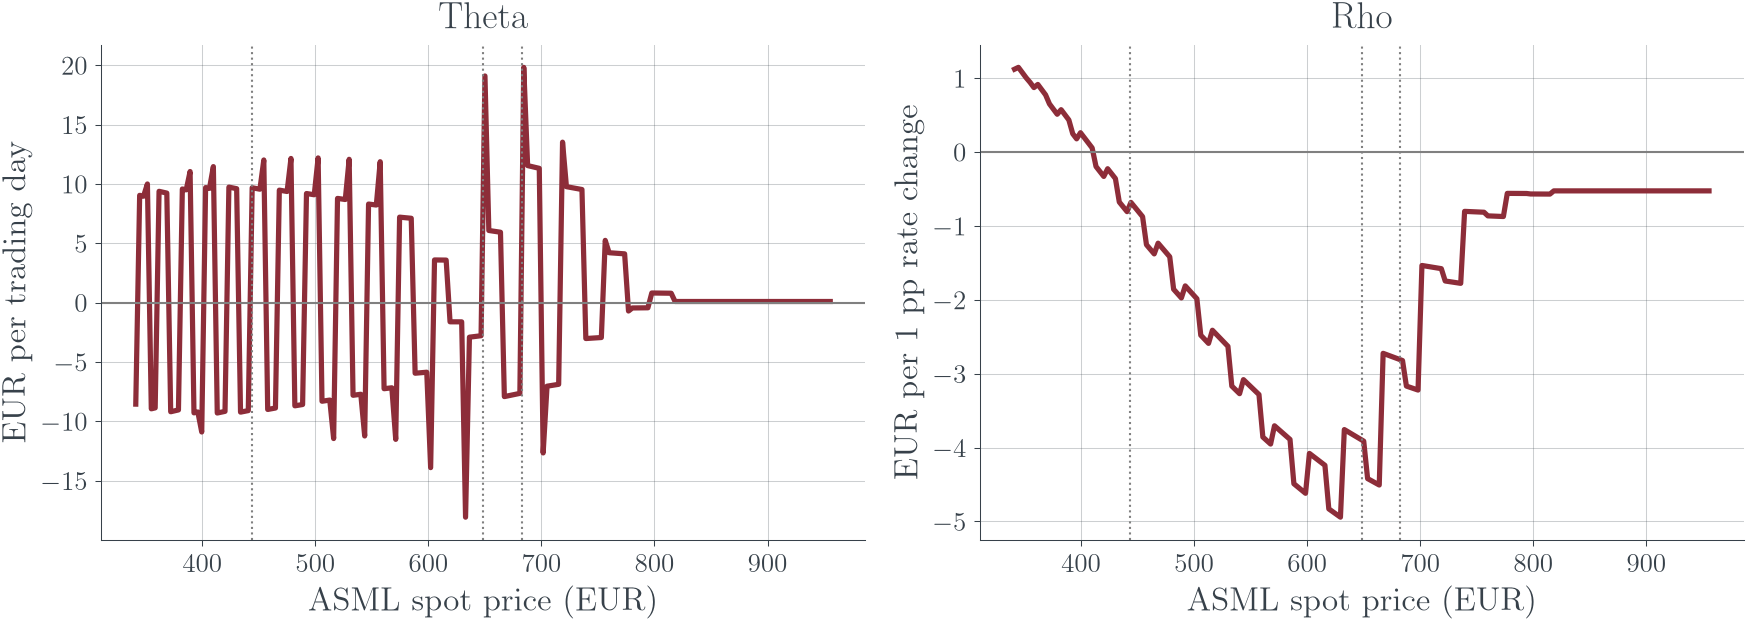

In [19]:
# Plot Theta and Rho across the spot-price range
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5), dpi=150)

axes[0].plot(
    extended_greeks_spot_df["spot"],
    extended_greeks_spot_df["theta"],
    lw=2.5,
)
axes[0].set_title("Theta", pad=8)
axes[0].set_ylabel("EUR per trading day")

axes[1].plot(
    extended_greeks_spot_df["spot"],
    extended_greeks_spot_df["rho"],
    lw=2.5,
)
axes[1].set_title("Rho", pad=8)
axes[1].set_ylabel("EUR per 1 pp rate change")

# Apply consistent formatting and mark economically relevant contract levels
for ax in axes:
    for level in (
        PRODUCT_PARAMS["BARRIER"],
        PRODUCT_PARAMS["LEVELS"][1],
        PRODUCT_PARAMS["LEVELS"][0],
    ):
        ax.axvline(level, ls=":", color="gray", lw=1)

    ax.axhline(0, color="gray", lw=1)
    ax.set_xlabel("ASML spot price (EUR)")
    ax.grid(alpha=0.25)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

plt.tight_layout()
plt.show()

### VII. Replicating Portfolio

In [ ]:
# Number of certificates to replicate (obviously only one)
N_CERT = 1

dt = 1 / PRODUCT_PARAMS["TRADING_DAYS"]

portfolio_vals = []
bond_vals = []
equity_vals = []
prod_vals = []
hedge_shares = []
dates = []
deltas = []

# Initialize on the first valuation date
row0 = valuation_df.iloc[0]

val_date = row0["Datum"].to_pydatetime()
spot = row0["underlying_price"]
sigma0 = row0["hist_volatility"]

# Build the remaining daily term structure on the first valuation date
b0, b1, b2, b3, t1, t2 = row0[
    ["beta0", "beta1", "beta2", "beta3", "tau1", "tau2"]
]

n_steps = idx_of(
    PRODUCT_PARAMS["MATURITY"],
    val_date,
    PRODUCT_PARAMS,
)

horizons = (
    np.arange(1, n_steps + 1)
    / PRODUCT_PARAMS["TRADING_DAYS"]
)

R_zero = nelson_siegel_svensson_model(
    horizons,
    b0,
    b1,
    b2,
    b3,
    t1,
    t2,
)

r_vec = zero_to_short(
    R_zero,
    dt,
)

# Price and Delta on the first valuation date
pv0, delta0, *_ = price_and_greeks(
    spot=spot,
    sigma=sigma0,
    val_date=val_date,
    r_vec=r_vec,
    params=PRODUCT_PARAMS,
    spot_bump_pct=0.01,
    vega_bump=0.005,
)

# Initial stock and cash positions
shares = delta0 * N_CERT
cash = pv0 * N_CERT - shares * spot

# Store day 0
prod_vals.append(pv0 * N_CERT)
equity_vals.append(shares * spot)
bond_vals.append(cash)
portfolio_vals.append(cash + shares * spot)
hedge_shares.append(shares)
dates.append(val_date)
deltas.append(delta0)

In [21]:
# Daily self-financing rebalancing loop
for _, row in valuation_df.iloc[1:].iterrows():
    val_date = row["Datum"].to_pydatetime()
    spot = row["underlying_price"]
    sigma_daily = row["hist_volatility"]

    # Build the remaining daily term structure
    b0, b1, b2, b3, t1, t2 = row[
        ["beta0", "beta1", "beta2", "beta3", "tau1", "tau2"]
    ]

    n_steps = idx_of(
        PRODUCT_PARAMS["MATURITY"],
        val_date,
        PRODUCT_PARAMS,
    )

    horizons = (
        np.arange(1, n_steps + 1)
        / PRODUCT_PARAMS["TRADING_DAYS"]
    )

    R_zero = nelson_siegel_svensson_model(
        horizons,
        b0,
        b1,
        b2,
        b3,
        t1,
        t2,
    )

    r_vec = zero_to_short(
        R_zero,
        dt,
    )

    # Accrue the cash position at the current short rate
    r_short = r_vec[0]
    cash *= np.exp(r_short * dt)

    # Reprice the certificate and compute the new Delta
    pv, delta_new, *_ = price_and_greeks(
        spot=spot,
        sigma=sigma_daily,
        val_date=val_date,
        r_vec=r_vec,
        params=PRODUCT_PARAMS,
        spot_bump_pct=0.01,
        vega_bump=0.005,
    )

    # Rebalance the stock position self-financingly
    target_shares = delta_new * N_CERT
    d_shares = target_shares - shares

    cash -= d_shares * spot
    shares = target_shares

    # Store values
    prod_vals.append(pv * N_CERT)
    equity_vals.append(shares * spot)
    bond_vals.append(cash)
    portfolio_vals.append(cash + shares * spot)
    hedge_shares.append(shares)
    dates.append(val_date)
    deltas.append(delta_new)

In [22]:
# Create a DataFrame to hold the replication dynamics
replication_dynamic_df = pd.DataFrame(
    {
        "Datum": dates,
        "product_value": prod_vals,
        "equity_value": equity_vals,
        "bond_value": bond_vals,
        "portfolio_value": portfolio_vals,
        "shares": hedge_shares,
        "delta": deltas,
    }
)

replication_dynamic_df["equity_fraction"] = (
    replication_dynamic_df["equity_value"]
    / replication_dynamic_df["portfolio_value"]
)

replication_dynamic_df["bond_fraction"] = (
    replication_dynamic_df["bond_value"]
    / replication_dynamic_df["portfolio_value"]
)

replication_dynamic_df.head()

,Datum,product_value,equity_value,bond_value,portfolio_value,shares,delta,equity_fraction,bond_fraction
0,2025-12-15,1087.170080,153.856300,933.313780,1087.170080,0.165259,0.165259,0.141520,0.858480
1,2025-12-16,1086.833238,128.043407,955.497174,1083.540580,0.140924,0.140924,0.118171,0.881829
2,2025-12-17,1076.325098,251.702194,827.036512,1078.738706,0.287989,0.287989,0.233330,0.766670
3,2025-12-18,1080.715685,221.317294,862.871018,1084.188313,0.247919,0.247919,0.204132,0.795868
4,2025-12-19,1084.786931,326.070172,760.391770,1086.461943,0.361657,0.361657,0.300121,0.699879


/var/folders/6v/992p8knd6g5flm6m0p856jlw0000gn/T/ipykernel_83487/1655038053.py:45: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


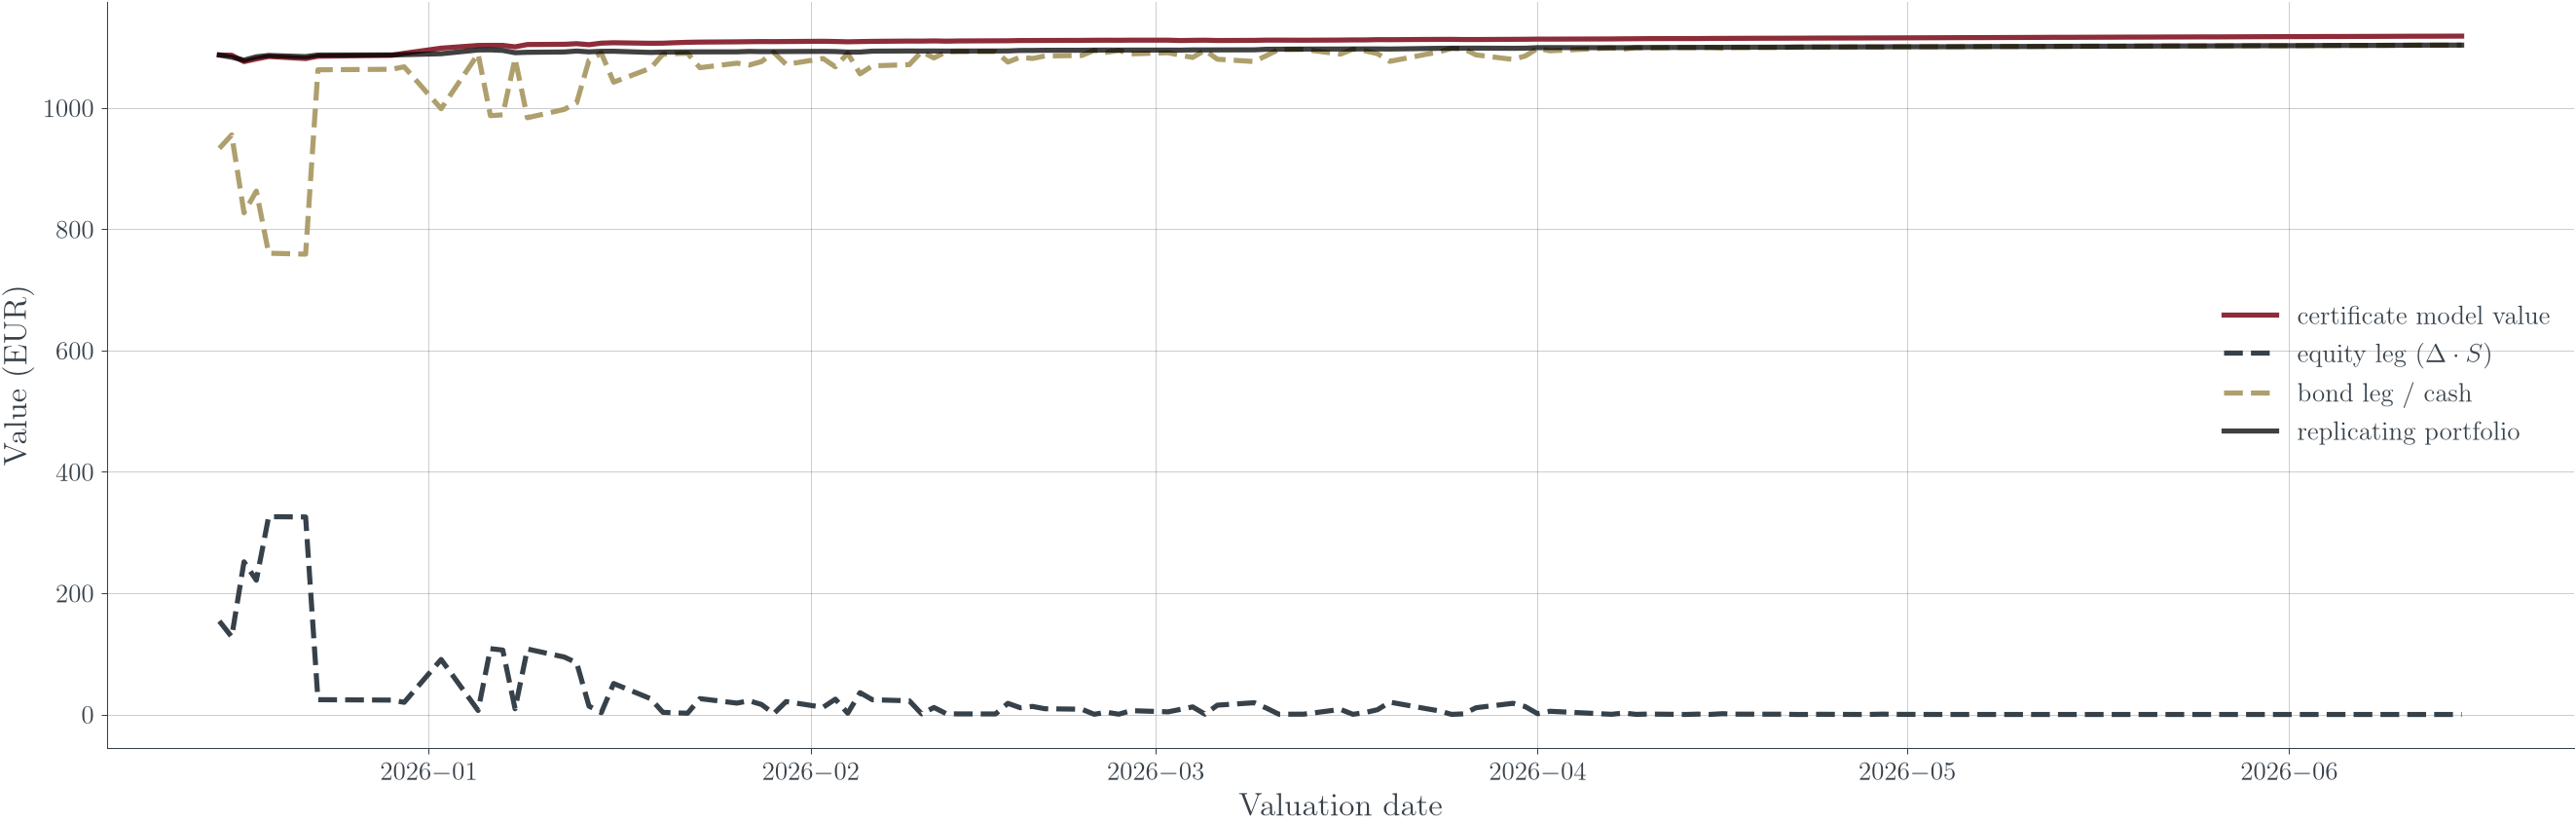

In [ ]:
# Plot the tracking performance of the dynamic replication portfolio and its individual legs
fig, ax = plt.subplots(figsize=(18, 6), dpi=150)

ax.plot(
    replication_dynamic_df["Datum"],
    replication_dynamic_df["product_value"],
    label="certificate model value",
    lw=2.5,
)

ax.plot(
    replication_dynamic_df["Datum"],
    replication_dynamic_df["equity_value"],
    "--",
    label=r"equity leg ($\Delta \cdot S$)",
    lw=2.5,
)

ax.plot(
    replication_dynamic_df["Datum"],
    replication_dynamic_df["bond_value"],
    "--",
    label="bond leg / cash",
    lw=2.5,
)

ax.plot(
    replication_dynamic_df["Datum"],
    replication_dynamic_df["portfolio_value"],
    color="k",
    alpha=0.75,
    label="replicating portfolio",
    lw=2.5,
)

ax.set_xlabel("Valuation date")
ax.set_ylabel("Value (EUR)")
ax.grid(alpha=0.25)
ax.legend(loc="best", frameon=False)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.tight_layout()

# Save figure
plt.savefig(
    "figs/part2_replication_dynamic.pdf",
    bbox_inches="tight",
)

plt.show()

/var/folders/6v/992p8knd6g5flm6m0p856jlw0000gn/T/ipykernel_83487/105928551.py:20: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


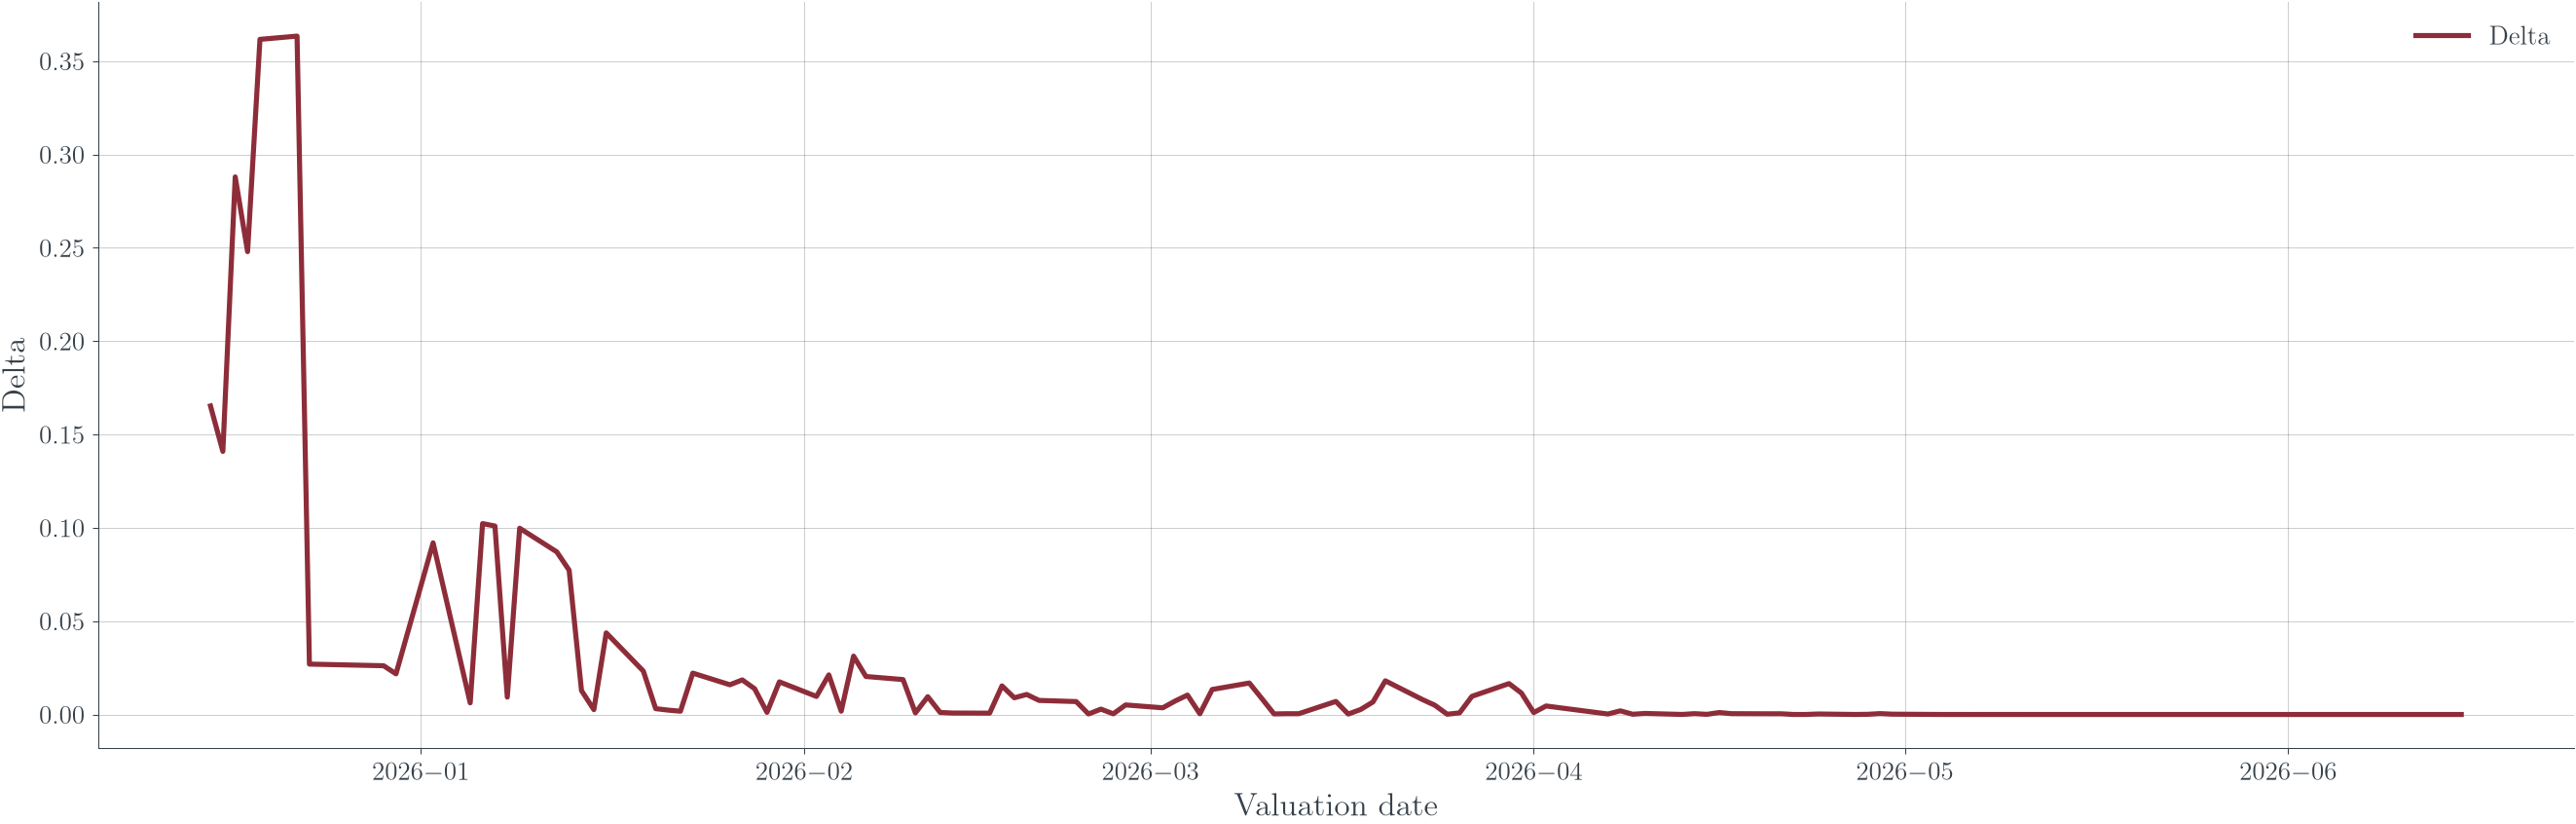

In [ ]:
# Plot the historical trajectory of the replicating portfolio's Delta equity fraction
fig, ax = plt.subplots(figsize=(18, 6), dpi=150)

ax.plot(
    replication_dynamic_df["Datum"],
    replication_dynamic_df["delta"],
    label="Delta",
    lw=2.5,
)

ax.set_xlabel("Valuation date")
ax.set_ylabel("Delta")
ax.grid(alpha=0.25)
ax.legend(loc="upper right", frameon=False)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.tight_layout()

plt.show()

In [25]:
# Calculate error metrics for the dynamic replication portfolio
metrics_repl = error_metrics(
    np.array(replication_dynamic_df["product_value"]),
    np.array(replication_dynamic_df["portfolio_value"]),
)

pd.Series(metrics_repl).to_frame("Error")

,Error
ME,13.692125
MAE,13.910097
RMSE,14.393818
MPE,1.247384
90%-|e|,16.378476
R²,0.185144


In [26]:
# Equity fraction as a function of the ASML spot price
replication_spot_df = greeks_spot_df[
    [
        "spot",
        "price",
        "delta_smooth",
    ]
].copy()

# Local value invested in ASML shares
replication_spot_df["equity_value"] = (
    replication_spot_df["delta_smooth"]
    * replication_spot_df["spot"]
)

# Equity fraction of the local replicating portfolio
replication_spot_df["equity_fraction"] = (
    replication_spot_df["equity_value"]
    / replication_spot_df["price"]
)

replication_spot_df.head()

,spot,price,delta_smooth,equity_value,equity_fraction
0,341.250000,598.965552,1.603878,547.323285,0.913781
1,344.681564,602.578087,1.609096,554.625880,0.920422
2,348.113128,605.181497,1.613654,561.734293,0.928208
3,351.544693,607.784907,1.617566,568.646869,0.935605
4,354.976257,629.246297,1.620847,575.362155,0.914367


/var/folders/6v/992p8knd6g5flm6m0p856jlw0000gn/T/ipykernel_83487/1673620810.py:36: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


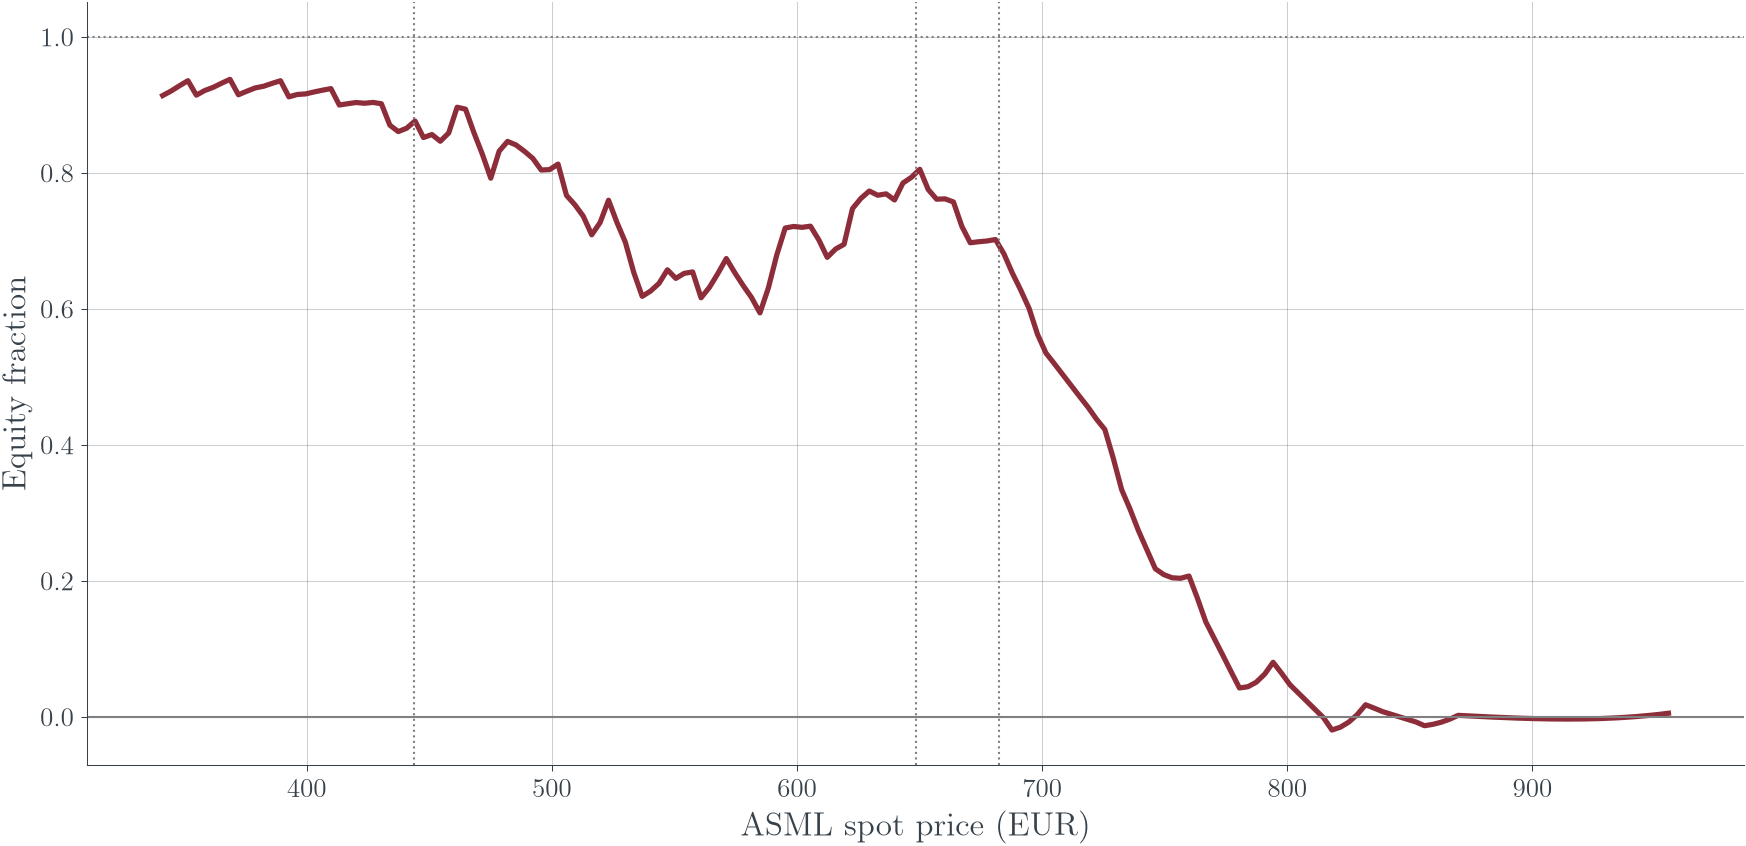

In [ ]:
# Plot the equity fraction of the replicating portfolio as a function of the ASML spot price
fig, ax = plt.subplots(figsize=(12, 6), dpi=150)

ax.plot(
    replication_spot_df["spot"],
    replication_spot_df["equity_fraction"],
    lw=2.5,
)

# Contractual reference levels
thresholds = {
    "Barrier": PRODUCT_PARAMS["BARRIER"],
    "2nd autocall": PRODUCT_PARAMS["LEVELS"][1],
    "1st autocall": PRODUCT_PARAMS["LEVELS"][0],
}

# Mark the barrier and autocall levels to support interpretation of sensitivity changes
for _, level in thresholds.items():
    ax.axvline(
        level,
        ls=":",
        color="gray",
        lw=1,
    )

ax.axhline(0, color="gray", lw=1)
ax.axhline(1, color="gray", lw=1, ls=":")

ax.set_xlabel("ASML spot price (EUR)")
ax.set_ylabel("Equity fraction")
ax.grid(alpha=0.25)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.tight_layout()

# Save figure
plt.savefig(
    "figs/part2_equity_fraction.pdf",
    bbox_inches="tight",
)

plt.show()

## Part 3

The following code cell defines the given values and further serves as setup for the subsequent tasks.

In [28]:
# Initial capital and simulation setup
INITIAL_CAPITAL = 10_000
T_INSURANCE = 1.0
N_SIM = 100_000

# Separate seeds for reproducible and independent simulations
RNG_SEED_PATHS = 42
RNG_SEED_STRESS = 43

# Define initial ASML price for the portfolio-insurance analysis
S0_PI = asml_df["underlying_price"].iloc[-1]

# Estimate drift and volatility from historical ASML log returns
mu_PI = (
    asml_df["log_return"].mean()
    * PRODUCT_PARAMS["TRADING_DAYS"]
)

sigma_PI = (
    asml_df["log_return"].std()
    * np.sqrt(PRODUCT_PARAMS["TRADING_DAYS"])
)

# Recompute the one-year risk-free rate from the latest Svensson parameters
latest_rate_row = valuation_df.iloc[-1]

b0, b1, b2, b3, t1, t2 = latest_rate_row[
    ["beta0", "beta1", "beta2", "beta3", "tau1", "tau2"]
]

# Only a one-year zero rate is needed for Black-Scholes put pricing
horizons_PI = np.array([T_INSURANCE])

R_zero_PI = nelson_siegel_svensson_model(
    horizons_PI,
    b0,
    b1,
    b2,
    b3,
    t1,
    t2,
)

r_PI = R_zero_PI[0]

print("Initial ASML price:", S0_PI)
print("Annualized drift:", mu_PI)
print("Annualized volatility:", sigma_PI)
print("Risk-free rate:", r_PI)

Initial ASML price: 1622.2
Annualized drift: 0.28980171540219285
Annualized volatility: 0.38403175235242176
Risk-free rate: 0.024851868137555827


### VIII. Performance analysis (without risk management)

In [29]:
# Simulate one-year ASML price paths under geometric Brownian motion
dt_PI = 1 / PRODUCT_PARAMS["TRADING_DAYS"]
n_steps_PI = int(T_INSURANCE / dt_PI)

# Initialize the random generator directly before drawing the base paths
rng_paths = np.random.default_rng(RNG_SEED_PATHS)

z_PI = rng_paths.standard_normal(
    size=(N_SIM, n_steps_PI)
)

drift_PI = (
    (mu_PI - 0.5 * sigma_PI**2)
    * dt_PI
)

shock_PI = (
    sigma_PI
    * np.sqrt(dt_PI)
    * z_PI
)

# Convert simulated log-return paths into stock-price paths
log_paths_PI = np.cumsum(
    drift_PI + shock_PI,
    axis=1,
)

log_paths_PI = np.hstack(
    [np.zeros((N_SIM, 1)), log_paths_PI]
)

S_paths_PI = (
    S0_PI
    * np.exp(log_paths_PI)
)

S_T_PI = S_paths_PI[:, -1]

In [30]:
# Invest the full initial capital in ASML
n_shares_unhedged = (
    INITIAL_CAPITAL
    / S0_PI
)

terminal_wealth_unhedged = (
    n_shares_unhedged
    * S_T_PI
)

# Calculate the unhedged return
returns_unhedged = (
    terminal_wealth_unhedged
    / INITIAL_CAPITAL
    - 1
)

In [31]:
# Compute risk metrics for the unhedged ASML investment
summary_unhedged = risk_metrics(returns_unhedged)

pd.Series(summary_unhedged).to_frame("Unhedged portfolio")

,Unhedged portfolio
E[R],0.337491
Sigma,0.536664
VaR 95%,0.340299
CVaR 95%,0.432102
P(loss),0.286010
5% quantile,-0.340299
Skewness,1.318446
Excess kurtosis,3.392981


/var/folders/6v/992p8knd6g5flm6m0p856jlw0000gn/T/ipykernel_83487/401734405.py:46: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


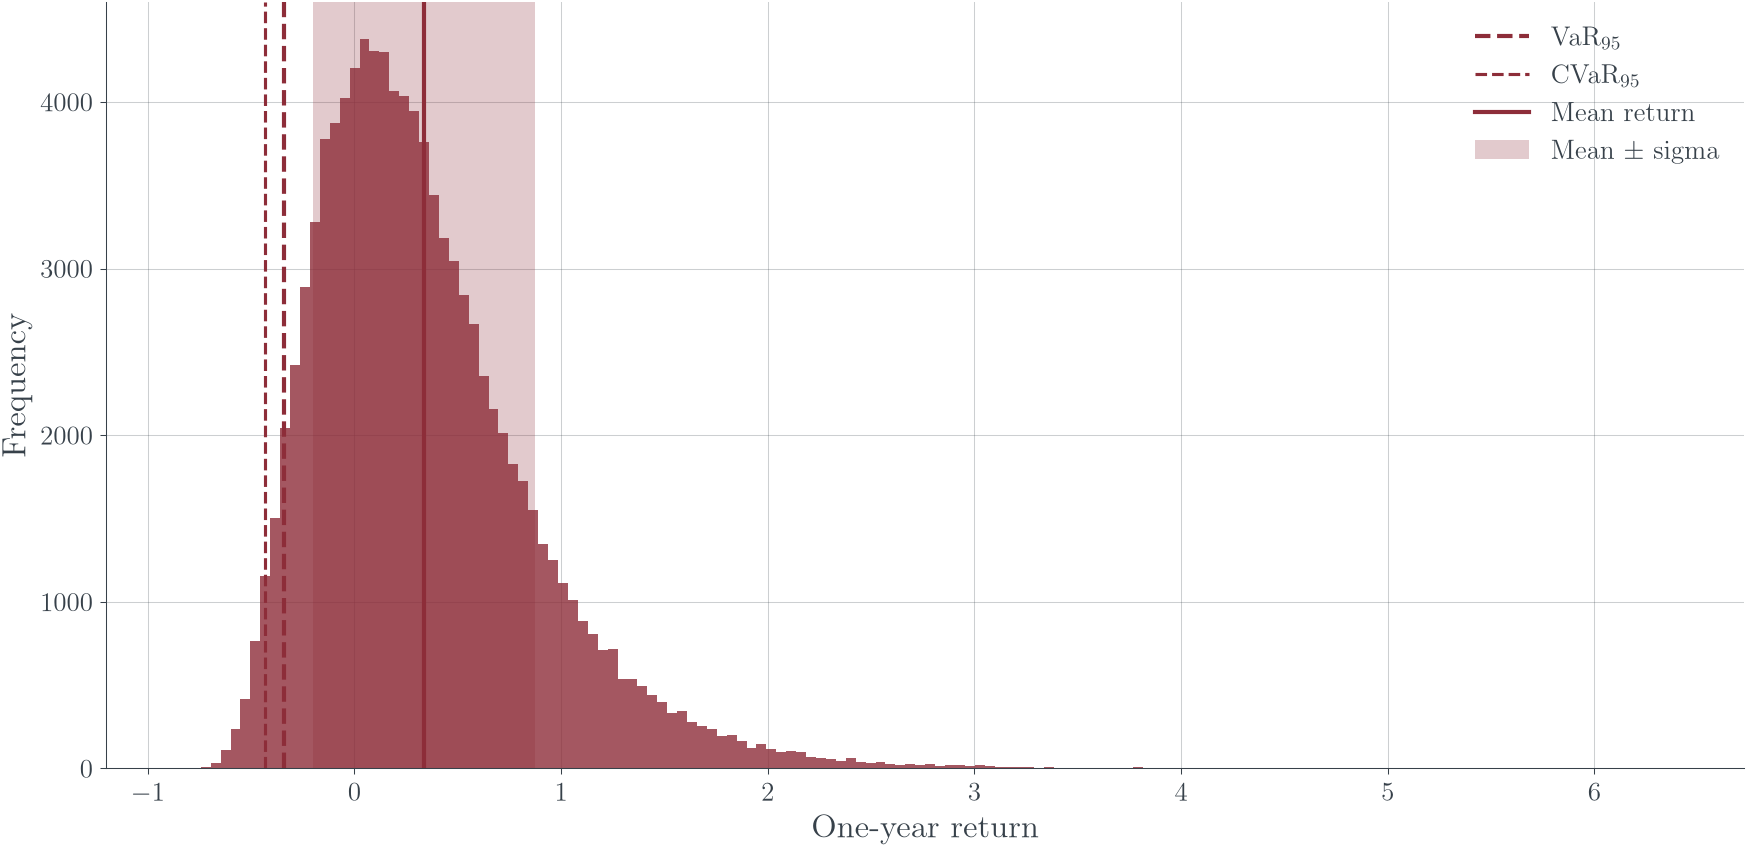

In [32]:
# Visualize the simulated one-year return distribution
fig, ax = plt.subplots(figsize=(12, 6), dpi=150)

ax.hist(
    returns_unhedged,
    bins=150,
    alpha=0.8,
)

ax.axvline(
    -summary_unhedged["VaR 95%"],
    linestyle="--",
    lw=2,
    label=r"$\mathrm{VaR}_{95}$",
)

ax.axvline(
    -summary_unhedged["CVaR 95%"],
    linestyle="--",
    lw=1.5,
    label=r"$\mathrm{CVaR}_{95}$",
)

ax.axvline(
    summary_unhedged["E[R]"],
    linestyle="-",
    lw=2,
    label="Mean return",
)

ax.axvspan(
    summary_unhedged["E[R]"] - summary_unhedged["Sigma"],
    summary_unhedged["E[R]"] + summary_unhedged["Sigma"],
    alpha=0.25,
    label=r"Mean $\pm$ sigma",
)

ax.set_xlabel("One-year return")
ax.set_ylabel("Frequency")
ax.legend(loc="best", frameon=False)
ax.grid(alpha=0.25)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.tight_layout()

plt.show()

### IX. Performance analysis (with risk management)

In [33]:
# Grid of put-budget fractions and strike moneyness levels
put_budget_fractions = np.arange(0.00, 0.31, 0.01)
strike_moneyness_grid = np.arange(0.70, 1.31, 0.01)

insurance_results = []

# Evaluate each portfolio-insurance design
for put_budget_fraction in put_budget_fractions:
    equity_budget = (
        (1 - put_budget_fraction)
        * INITIAL_CAPITAL
    )

    n_shares = (
        equity_budget
        / S0_PI
    )

    for strike_moneyness in strike_moneyness_grid:
        K = (
            strike_moneyness
            * S0_PI
        )

        put_price = black_scholes_put(
            S0=S0_PI,
            K=K,
            r=r_PI,
            sigma=sigma_PI,
            T=T_INSURANCE,
        )

        # Number of puts bought with the allocated insurance budget
        if put_price > 0:
            n_puts = (
                put_budget_fraction
                * INITIAL_CAPITAL
                / put_price
            )
        else:
            n_puts = 0.0

        # Terminal portfolio value across all Monte Carlo paths
        equity_leg = (
            n_shares
            * S_T_PI
        )

        put_leg = (
            n_puts
            * np.maximum(K - S_T_PI, 0)
        )

        terminal_wealth_insured = (
            equity_leg
            + put_leg
        )

        returns_insured = (
            terminal_wealth_insured
            / INITIAL_CAPITAL
            - 1
        )

        stats = risk_metrics(returns_insured)

        insurance_results.append(
            {
                "put_budget_fraction": put_budget_fraction,
                "strike_moneyness": strike_moneyness,
                "strike": K,
                "put_price": put_price,
                "n_shares": n_shares,
                "n_puts": n_puts,
                **stats,
            }
        )

insurance_df = pd.DataFrame(insurance_results)

insurance_df.head()

,put_budget_fraction,strike_moneyness,strike,put_price,n_shares,n_puts,E[R],Sigma,VaR 95%,CVaR 95%,P(loss),5% quantile,Skewness,Excess kurtosis
0,0.0,0.70,1135.540,42.921028,6.164468,0.0,0.337491,0.536664,0.340299,0.432102,0.28601,-0.340299,1.318446,3.392981
1,0.0,0.71,1151.762,46.352287,6.164468,0.0,0.337491,0.536664,0.340299,0.432102,0.28601,-0.340299,1.318446,3.392981
2,0.0,0.72,1167.984,49.956379,6.164468,0.0,0.337491,0.536664,0.340299,0.432102,0.28601,-0.340299,1.318446,3.392981
3,0.0,0.73,1184.206,53.735599,6.164468,0.0,0.337491,0.536664,0.340299,0.432102,0.28601,-0.340299,1.318446,3.392981
4,0.0,0.74,1200.428,57.692011,6.164468,0.0,0.337491,0.536664,0.340299,0.432102,0.28601,-0.340299,1.318446,3.392981


In [34]:
# Strategies with the lowest 95% VaR
insurance_df.sort_values(
    "VaR 95%",
    ascending=True,
).head(10)

,put_budget_fraction,strike_moneyness,strike,put_price,n_shares,n_puts,E[R],Sigma,VaR 95%,CVaR 95%,P(loss),5% quantile,Skewness,Excess kurtosis
1673,0.26,1.31,2125.082,561.132827,4.561706,4.633484,0.131349,0.288560,0.029908,0.030253,0.58878,-0.029908,2.805797,11.372875
1610,0.25,1.30,2108.860,548.568337,4.623351,4.557317,0.138317,0.297074,0.031859,0.032842,0.57513,-0.031859,2.734366,10.822381
1609,0.25,1.29,2092.638,536.094897,4.623351,4.663353,0.137352,0.297614,0.032114,0.032307,0.57513,-0.032114,2.726175,10.759900
1545,0.24,1.27,2060.194,511.429978,4.684996,4.692725,0.143485,0.306743,0.034725,0.034763,0.56064,-0.034725,2.649347,10.186967
1611,0.25,1.31,2125.082,561.132827,4.623351,4.455273,0.139278,0.296561,0.035231,0.037734,0.57513,-0.035231,2.741605,10.880698
1672,0.26,1.30,2108.860,548.568337,4.561706,4.739610,0.130350,0.289138,0.036334,0.037165,0.58878,-0.036334,2.795924,11.299663
1546,0.24,1.28,2076.416,523.714702,4.684996,4.582648,0.144424,0.306209,0.037499,0.039023,0.56064,-0.037499,2.656985,10.244249
1608,0.25,1.28,2076.416,523.714702,4.623351,4.773591,0.136379,0.298184,0.038593,0.039298,0.57513,-0.038593,2.716997,10.693052
1481,0.23,1.25,2027.750,487.155999,4.746640,4.721280,0.149754,0.315943,0.039928,0.040306,0.54649,-0.039928,2.575168,9.651088
1735,0.27,1.31,2125.082,561.132827,4.500062,4.811695,0.123420,0.280787,0.040847,0.042264,0.59849,-0.040847,2.865965,11.863411


In [35]:
# Strategies that reduce VaR relative to the unhedged portfolio
var_unhedged = summary_unhedged["VaR 95%"]

insurance_df[
    insurance_df["VaR 95%"] < var_unhedged
].sort_values(
    "E[R]",
    ascending=False,
).head(10)

,put_budget_fraction,strike_moneyness,strike,put_price,n_shares,n_puts,E[R],Sigma,VaR 95%,CVaR 95%,P(loss),5% quantile,Skewness,Excess kurtosis
123,0.01,1.31,2125.082,561.132827,6.102823,0.178211,0.329562,0.526251,0.328096,0.416327,0.28718,-0.328096,1.356404,3.536825
122,0.01,1.30,2108.860,548.568337,6.102823,0.182293,0.329524,0.526248,0.327961,0.416131,0.28730,-0.327961,1.356771,3.537107
121,0.01,1.29,2092.638,536.094897,6.102823,0.186534,0.329485,0.526245,0.327823,0.415930,0.28739,-0.327823,1.357135,3.537359
120,0.01,1.28,2076.416,523.714702,6.102823,0.190944,0.329446,0.526243,0.327682,0.415723,0.28757,-0.327682,1.357497,3.537584
119,0.01,1.27,2060.194,511.429978,6.102823,0.195530,0.329407,0.526241,0.327538,0.415511,0.28765,-0.327538,1.357856,3.537779
118,0.01,1.26,2043.972,499.242981,6.102823,0.200303,0.329368,0.526240,0.327390,0.415292,0.28777,-0.327390,1.358212,3.537944
117,0.01,1.25,2027.750,487.155999,6.102823,0.205273,0.329328,0.526239,0.327239,0.415067,0.28783,-0.327239,1.358565,3.538080
116,0.01,1.24,2011.528,475.171344,6.102823,0.210450,0.329288,0.526239,0.327085,0.414836,0.28792,-0.327085,1.358915,3.538184
115,0.01,1.23,1995.306,463.291360,6.102823,0.215847,0.329248,0.526240,0.326927,0.414597,0.28801,-0.326927,1.359262,3.538258
114,0.01,1.22,1979.084,451.518413,6.102823,0.221475,0.329208,0.526241,0.326766,0.414352,0.28809,-0.326766,1.359605,3.538299


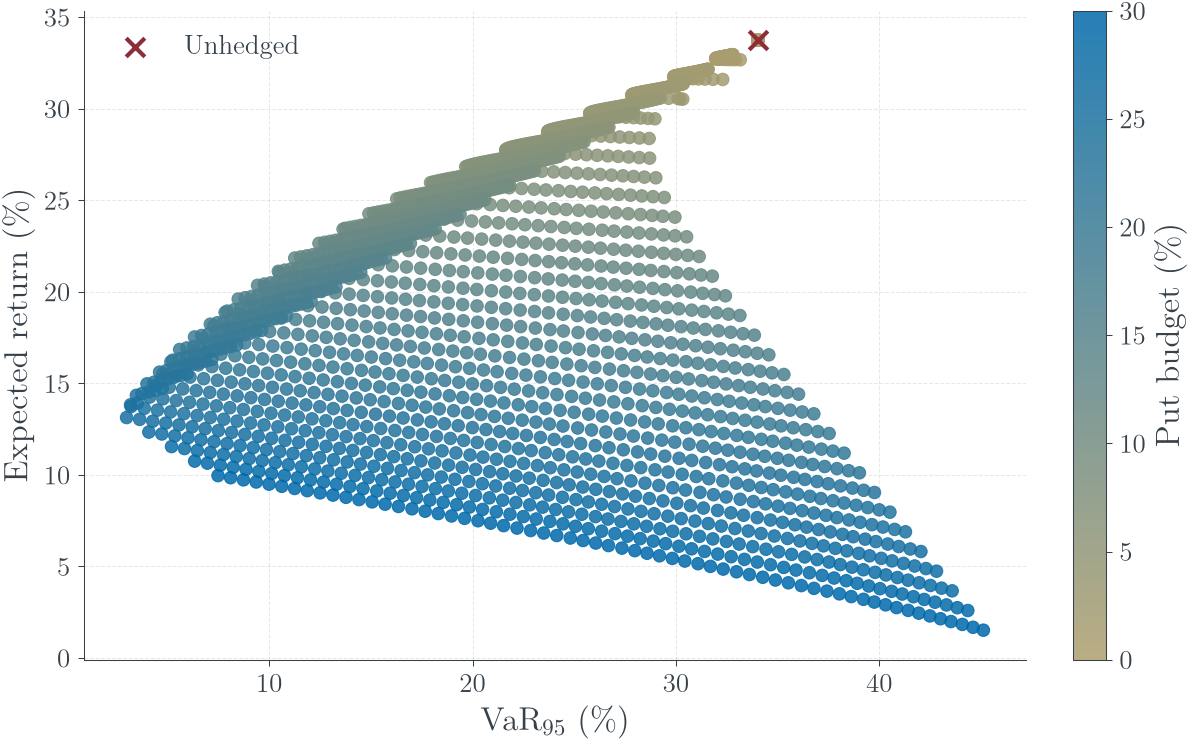

In [36]:
# Define a custom colormap
tue_cmap = mcolors.LinearSegmentedColormap.from_list(
    "TuebingenBudget", [rgb.tue_gold, rgb.tue_blue]
)

# Risk-return trade-off across all put-insurance strategies
fig, ax = plt.subplots(figsize=(8, 5), dpi=150, layout="constrained")

scatter = ax.scatter(
    insurance_df["VaR 95%"] * 100,
    insurance_df["E[R]"] * 100,
    c=insurance_df["put_budget_fraction"] * 100,
    cmap=tue_cmap,
    alpha=0.85,
)

ax.scatter(
    summary_unhedged["VaR 95%"] * 100,
    summary_unhedged["E[R]"] * 100,
    marker="x",
    s=80,
    linewidths=2.0,
    color=rgb.tue_red,
    label="Unhedged",
)

cbar = plt.colorbar(scatter, ax=ax)
cbar.set_label(r"Put budget (\%)", color=rgb.tue_dark)

ax.set_xlabel(r"VaR$_{95}$ (\%)", color=rgb.tue_dark)
ax.set_ylabel(r"Expected return (\%)", color=rgb.tue_dark)

ax.grid(True, linestyle="--", alpha=0.3, color=rgb.tue_gray)
ax.legend(loc="upper left", frameon=False)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.spines["left"].set_color(rgb.tue_dark)
ax.spines["bottom"].set_color(rgb.tue_dark)

ax.tick_params(colors=rgb.tue_dark)

# Save figure
plt.savefig(
    "figs/part3_insurance_risk_return.pdf",
    bbox_inches="tight",
)

plt.show()

In [37]:
# Selected strategies with fixed 90% strike
compact_strategy_table = insurance_df[
    (
        insurance_df["put_budget_fraction"].isin([0.00, 0.05, 0.10, 0.15])
    )
    &
    (
        np.isclose(insurance_df["strike_moneyness"], 0.90)
    )
].copy()

# Display the most relevant columns in a clean and sorted table
compact_strategy_table = compact_strategy_table[
    [
        "put_budget_fraction",
        "strike_moneyness",
        "E[R]",
        "VaR 95%",
        "CVaR 95%",
        "P(loss)",
    ]
].sort_values("put_budget_fraction")

compact_strategy_table

,put_budget_fraction,strike_moneyness,E[R],VaR 95%,CVaR 95%,P(loss)
20,0.00,0.9,0.337491,0.340299,0.432102,0.28601
330,0.05,0.9,0.288845,0.239720,0.275906,0.33334
640,0.10,0.9,0.240199,0.179265,0.184621,0.38607
950,0.15,0.9,0.191553,0.209248,0.222086,0.41074


### X. Stress scenario analysis

For Task X the selected strategy from the previous task is used as the best case. Based on the table, the clean choice is:

$$w=10\%, \quad K=0.9 \cdot S_0$$

because it gives the strongest VaR/CVaR reduction along the selected strategies.

In [38]:
# Stress-test the selected insurance strategy
BASE_PUT_BUDGET = 0.10
BASE_STRIKE_MONEYNESS = 0.90

# Simulate a 20% stock drop after half a year and continue the GBM path afterwards
n_half_PI = int(0.5 * n_steps_PI)

rng_stress = np.random.default_rng(RNG_SEED_STRESS)

z_second_half = rng_stress.standard_normal(
    size=(N_SIM, n_steps_PI - n_half_PI)
)

S_half_drop = (
    S_paths_PI[:, n_half_PI]
    * 0.80
)

log_second_half = np.cumsum(
    (mu_PI - 0.5 * sigma_PI**2) * dt_PI
    + sigma_PI * np.sqrt(dt_PI) * z_second_half,
    axis=1,
)

S_T_drop_PI = (
    S_half_drop
    * np.exp(log_second_half[:, -1])
)

# Define the set of stress scenarios to evaluate the robustness of the selected insurance strategy
stress_scenarios = {
    "Base": {
        "S_T": S_T_PI,
        "sigma_pricing": sigma_PI,
    },
    "Sigma +5pp": {
        "S_T": S_T_PI,
        "sigma_pricing": sigma_PI + 0.05,
    },
    "Sigma -5pp": {
        "S_T": S_T_PI,
        "sigma_pricing": max(sigma_PI - 0.05, 0.01),
    },
    "Crash -20%": {
        "S_T": S_T_drop_PI,
        "sigma_pricing": sigma_PI,
    },
    "Crash -20% & Sigma +5pp": {
        "S_T": S_T_drop_PI,
        "sigma_pricing": sigma_PI + 0.05,
    },
    "Crash -20% & Sigma -5pp": {
        "S_T": S_T_drop_PI,
        "sigma_pricing": max(sigma_PI - 0.05, 0.01),
    },
}

# Store full return distributions for the stress-scenario analysis
stress_returns = {}
stress_results = []

for scenario_name, scenario in stress_scenarios.items():
    returns_stress, strategy_info = evaluate_put_insurance_strategy(
        S_T=scenario["S_T"],
        put_budget_fraction=BASE_PUT_BUDGET,
        strike_moneyness=BASE_STRIKE_MONEYNESS,
        S0=S0_PI,
        initial_capital=INITIAL_CAPITAL,
        r=r_PI,
        sigma_pricing=scenario["sigma_pricing"],
        T=T_INSURANCE,
    )

    # Store the complete return distribution for later visualization
    stress_returns[scenario_name] = returns_stress

    stats = risk_metrics(returns_stress)

    stress_results.append(
        {
            "Scenario": scenario_name,
            "Put price": strategy_info["put_price"],
            "Number of puts": strategy_info["n_puts"],
            **stats,
        }
    )

stress_df = pd.DataFrame(stress_results).set_index("Scenario")

stress_df[
    [
        "Put price",
        "Number of puts",
        "E[R]",
        "Sigma",
        "VaR 95%",
        "CVaR 95%",
        "P(loss)",
    ]
]

,Put price,Number of puts,E[R],Sigma,VaR 95%,CVaR 95%,P(loss)
Scenario,,,,,,,
Base,145.92722,6.852731,0.240199,0.443812,0.179265,0.184621,0.38607
Sigma +5pp,174.14531,5.742331,0.234292,0.449063,0.188065,0.189037,0.38607
Sigma -5pp,118.00164,8.474458,0.248827,0.436981,0.170647,0.180331,0.37759
Crash -20%,145.92722,6.852731,0.051639,0.308034,0.182452,0.186234,0.61583
Crash -20% & Sigma +5pp,174.14531,5.742331,0.037191,0.317232,0.188671,0.189332,0.61583
Crash -20% & Sigma -5pp,118.00164,8.474458,0.072739,0.297417,0.176162,0.183111,0.57928


Heatmap (monochromatic scale): A clean gradient from light to dark Tübingen Blue shows magnitude objectively. (not used for the poster).

<>:72: SyntaxWarning: invalid escape sequence '\%'
<>:72: SyntaxWarning: invalid escape sequence '\%'
/var/folders/6v/992p8knd6g5flm6m0p856jlw0000gn/T/ipykernel_83487/4219481627.py:72: SyntaxWarning: invalid escape sequence '\%'
  cbar.set_label("Value (\%)")


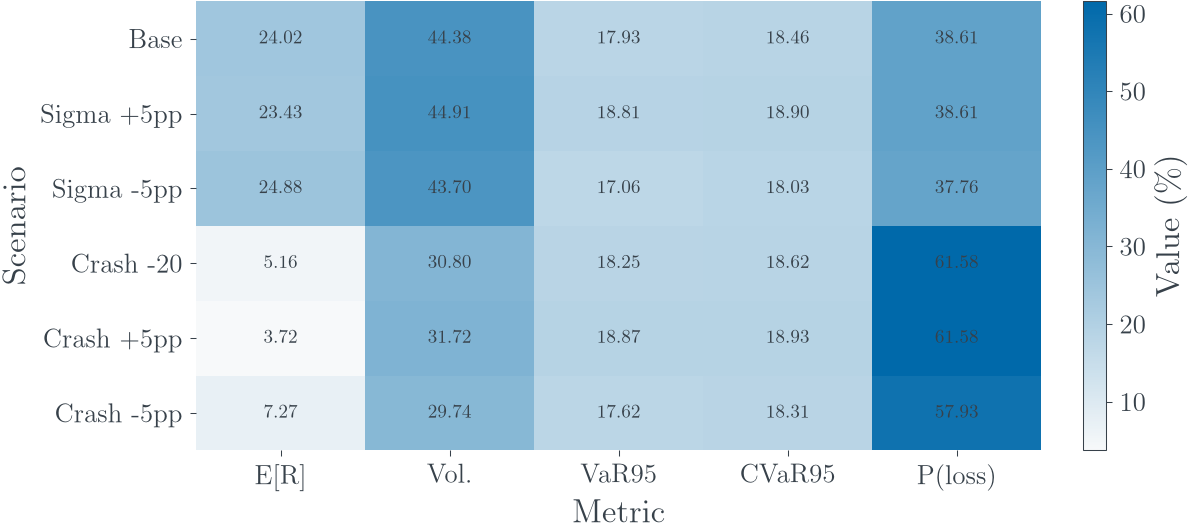

In [55]:
# Heatmap of stress-scenario risk and performance metrics
stress_plot_df = stress_df[
    [
        "E[R]",
        "Sigma",
        "VaR 95%",
        "CVaR 95%",
        "P(loss)",
    ]
].copy()

# Convert metrics to percentages for display
stress_plot_pct = stress_plot_df * 100

# Short column names for the plot
stress_plot_pct.columns = [
    "E[R]",
    "Vol.",
    "VaR95",
    "CVaR95",
    "P(loss)",
]

# Short row labels for compact plotting
stress_plot_pct.index = [
    "Base",
    "Sigma +5pp",
    "Sigma -5pp",
    "Crash -20%",
    "Crash +5pp",
    "Crash -5pp",
]

fig, ax = plt.subplots(figsize=(8, 3.6), dpi=150, layout="constrained")

# Interpolating from a very crisp, light neutral tint to tue_blue
tue_mono_cmap = mcolors.LinearSegmentedColormap.from_list(
    "TuebingenMono", ["#f7f9fa", rgb.tue_blue]
)

im = ax.imshow(
    stress_plot_pct.values,
    aspect="auto",
    cmap=tue_mono_cmap
)

# Add metric values inside the heatmap cells
for i in range(stress_plot_pct.shape[0]):
    for j in range(stress_plot_pct.shape[1]):
        val = stress_plot_pct.iloc[i, j]
        text_color = "white" if val > 35.0 else "black"

        ax.text(
            j,
            i,
            f"{stress_plot_pct.iloc[i, j]:.2f}",
            ha="center",
            va="center",
            fontsize=9,
        )

ax.set_xticks(np.arange(stress_plot_pct.shape[1]))
ax.set_xticklabels(stress_plot_pct.columns)

ax.set_yticks(np.arange(stress_plot_pct.shape[0]))
ax.set_yticklabels(stress_plot_pct.index)

ax.set_xlabel("Metric")
ax.set_ylabel("Scenario")

cbar = plt.colorbar(im, ax=ax)
cbar.set_label("Value (\%)")

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.spines["bottom"].set_visible(False)
ax.spines["left"].set_visible(False)

plt.show()

Heatmap (column-normalized): Normalizes each column independently to show relative severity within that metric. Since stress metrics have vastly different scales, column normalization reveals which risks deteriorate most under stress.

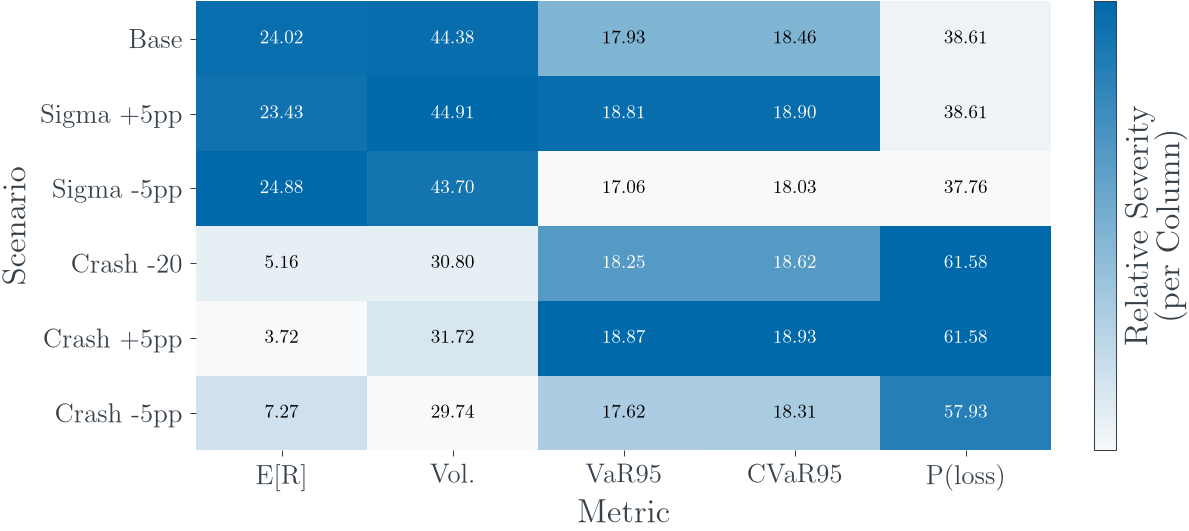

In [40]:
# Scale each column individually between 0 (lightest) and 1 (darkest)
df_min = stress_plot_pct.min()
df_max = stress_plot_pct.max()
normalized_values = (stress_plot_pct - df_min) / (df_max - df_min)

fig, ax = plt.subplots(figsize=(8, 3.6), dpi=150, layout="constrained")

# Interpolating from a very crisp, light neutral tint to tue_blue
tue_mono_cmap = mcolors.LinearSegmentedColormap.from_list(
    "TuebingenMono", ["#f7f9fa", rgb.tue_blue]
)

im = ax.imshow(
    normalized_values.values,
    aspect="auto",
    cmap=tue_mono_cmap
)

# Add metric values inside the heatmap cells
for i in range(stress_plot_pct.shape[0]):
    for j in range(stress_plot_pct.shape[1]):
        raw_val = stress_plot_pct.iloc[i, j]
        norm_val = normalized_values.iloc[i, j]
        text_color = "white" if norm_val > 0.55 else "black"

        ax.text(
            j,
            i,
            f"{raw_val:.2f}%",
            ha="center",
            va="center",
            fontsize=9,
            color=text_color,
        )

ax.set_xticks(np.arange(stress_plot_pct.shape[1]))
ax.set_xticklabels(stress_plot_pct.columns)

ax.set_yticks(np.arange(stress_plot_pct.shape[0]))
ax.set_yticklabels(stress_plot_pct.index)

ax.set_xlabel("Metric")
ax.set_ylabel("Scenario")

cbar = plt.colorbar(im, ax=ax)
cbar.set_label("Relative Severity\n(per Column)")
cbar.set_ticks([])  # Remove the tick marks

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.spines["bottom"].set_visible(False)
ax.spines["left"].set_visible(False)

# Save figure
plt.savefig(
    "figs/part3_stress_heatmap.pdf",
    bbox_inches="tight",
)

plt.show()

The following dot plot isolates the tail risk metrics (VaR₉₅ and CVaR₉₅) to highlight the spread between the 95% quantile and expected shortfall. A widening gap indicates that losses beyond the VaR threshold become increasingly severe under stress (not used for the poster).

<>:54: SyntaxWarning: invalid escape sequence '\%'
<>:54: SyntaxWarning: invalid escape sequence '\%'
/var/folders/6v/992p8knd6g5flm6m0p856jlw0000gn/T/ipykernel_83487/2170172175.py:54: SyntaxWarning: invalid escape sequence '\%'
  ax.set_xlabel("Loss measure (\%)")
/var/folders/6v/992p8knd6g5flm6m0p856jlw0000gn/T/ipykernel_83487/2170172175.py:62: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


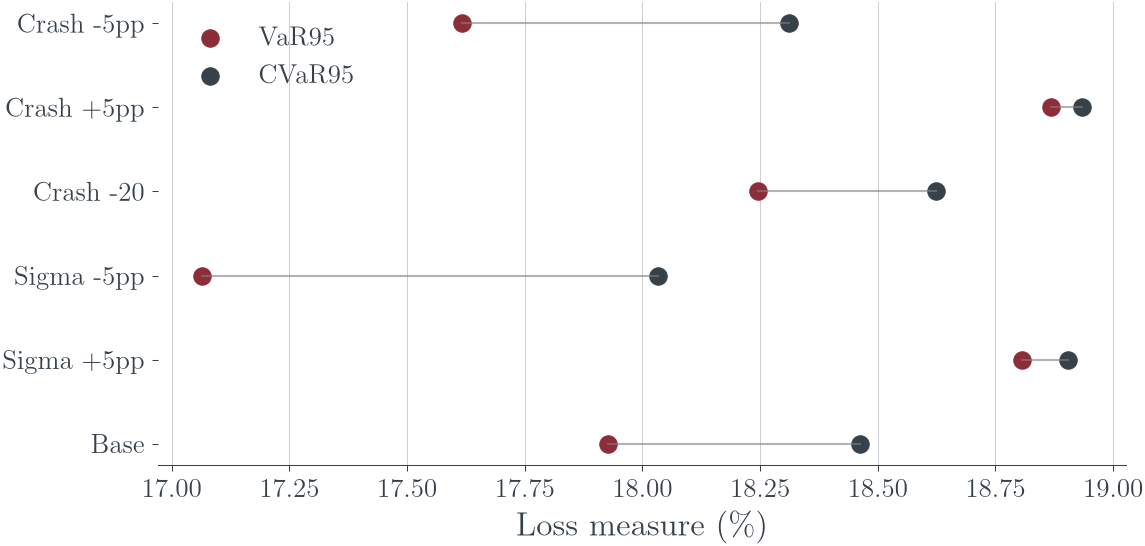

In [41]:
# Dot plot of downside-risk metrics across stress scenarios
stress_risk_plot_df = stress_df[
    [
        "VaR 95%",
        "CVaR 95%",
    ]
].copy() * 100

stress_risk_plot_df.index = [
    "Base",
    "Sigma +5pp",
    "Sigma -5pp",
    "Crash -20%",
    "Crash +5pp",
    "Crash -5pp",
]

fig, ax = plt.subplots(figsize=(8, 4), dpi=150)

y_pos = np.arange(len(stress_risk_plot_df))

ax.scatter(
    stress_risk_plot_df["VaR 95%"],
    y_pos,
    label="VaR95",
    s=70,
)

ax.scatter(
    stress_risk_plot_df["CVaR 95%"],
    y_pos,
    label="CVaR95",
    s=70,
)

for i in range(len(stress_risk_plot_df)):
    ax.plot(
        [
            stress_risk_plot_df["VaR 95%"].iloc[i],
            stress_risk_plot_df["CVaR 95%"].iloc[i],
        ],
        [
            y_pos[i],
            y_pos[i],
        ],
        lw=1,
        color="gray",
        alpha=0.6,
    )

ax.set_yticks(y_pos)
ax.set_yticklabels(stress_risk_plot_df.index)

ax.set_xlabel("Loss measure (\%)")
ax.legend(loc="upper left", frameon=False)
ax.grid(axis="x", alpha=0.25)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.spines["left"].set_visible(False)

plt.tight_layout()

plt.show()

The following distribution plots compare the full return distributions across stress scenarios to show how expected return, dispersion, and tail risk shift under changing option-pricing volatility and a mid-year crash. Common bins and axes ensure direct comparability across scenarios (not used for the poster).


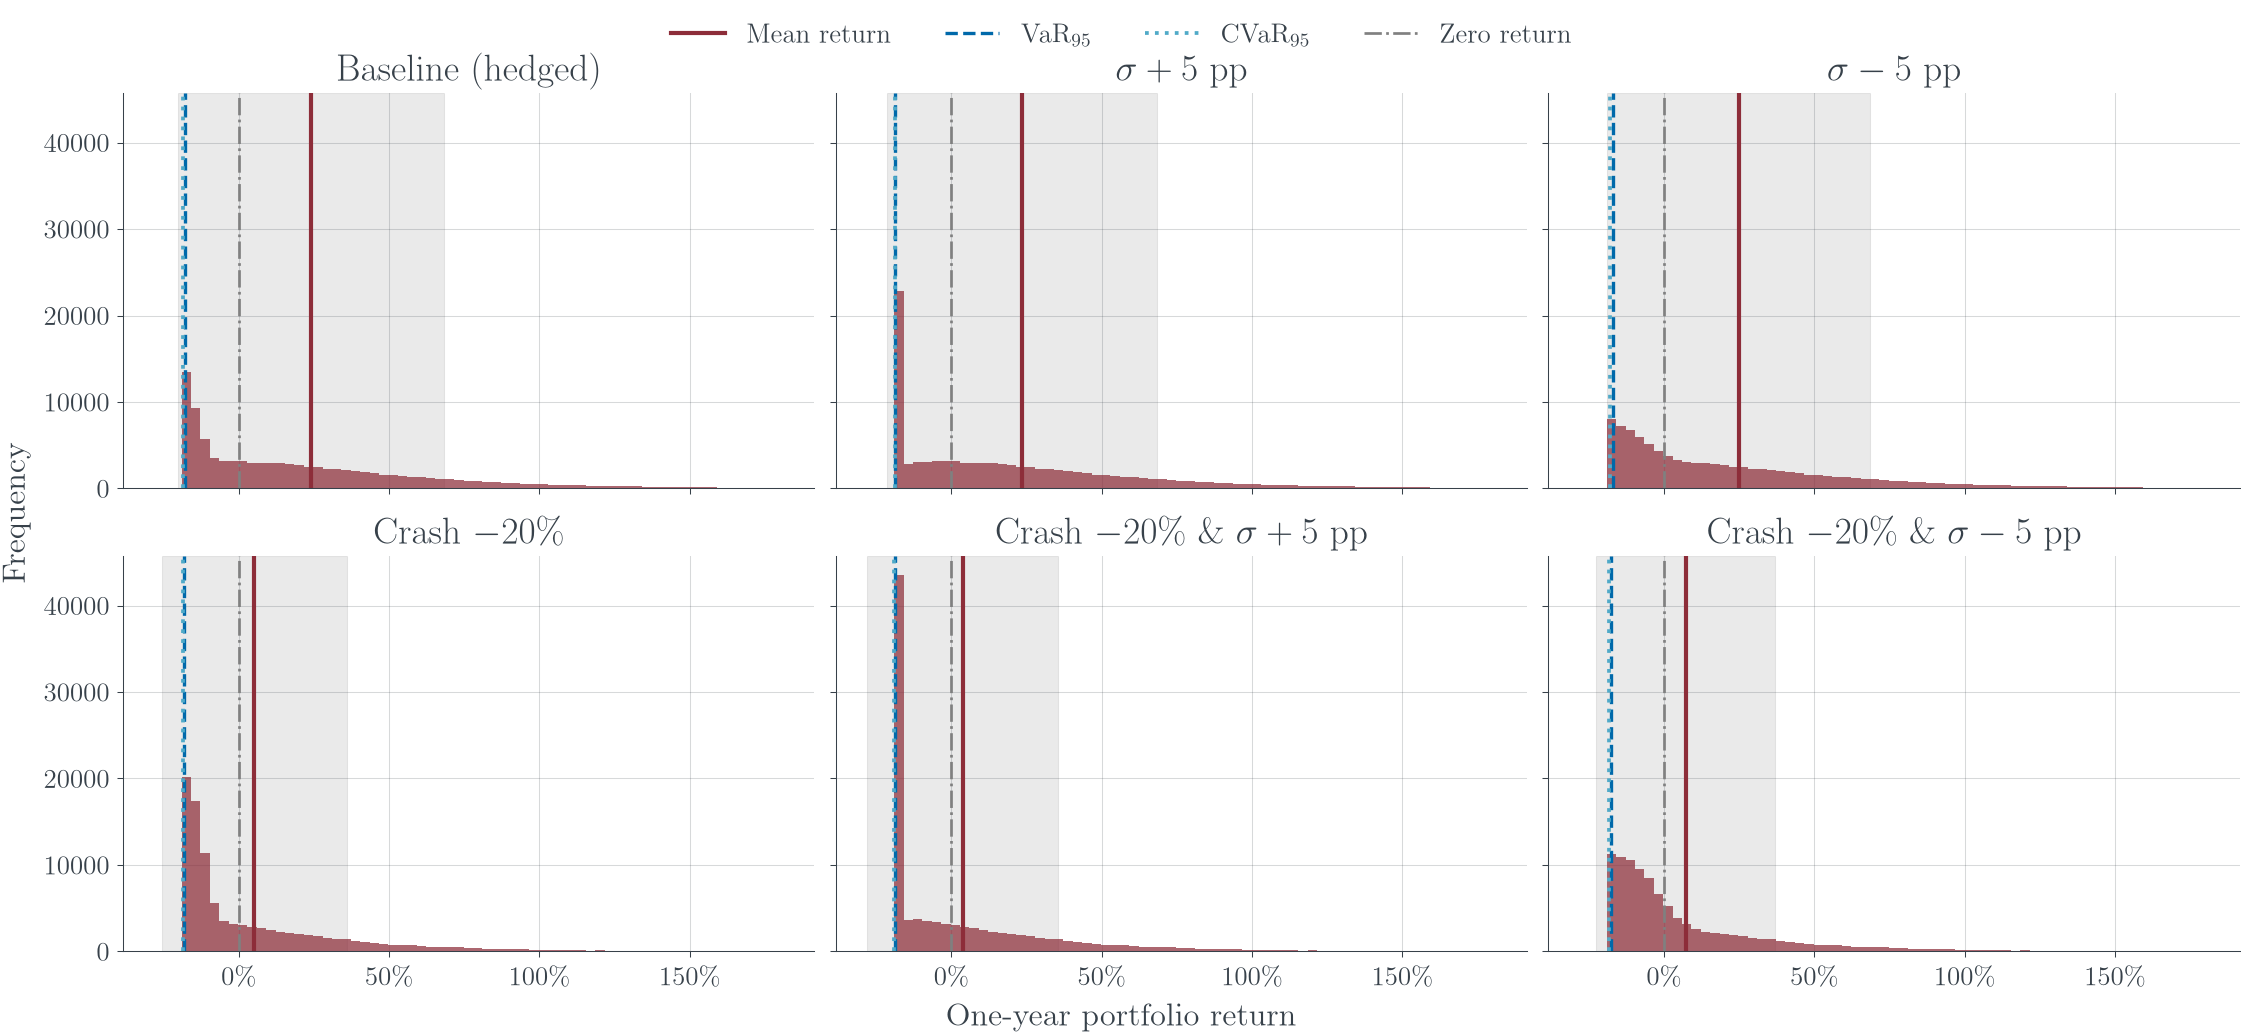

In [53]:
# Visualize the return distributions across all stress scenarios
scenario_order = [
    "Base",
    "Sigma +5pp",
    "Sigma -5pp",
    "Crash -20%",
    "Crash -20% & Sigma +5pp",
    "Crash -20% & Sigma -5pp",
]

scenario_titles = {
    "Base": "Baseline (hedged)",
    "Sigma +5pp": r"$\sigma + 5$ pp",
    "Sigma -5pp": r"$\sigma - 5$ pp",
    "Crash -20%": r"Crash $-20\%$",
    "Crash -20% & Sigma +5pp": r"Crash $-20\%$ \& $\sigma + 5$ pp",
    "Crash -20% & Sigma -5pp": r"Crash $-20\%$ \& $\sigma - 5$ pp",
}

# Use common display limits and common histogram bins for comparability
all_stress_returns = np.concatenate(
    [stress_returns[name] for name in scenario_order]
)

# Quantile-based limits prevent a few extreme right-tail observations
# from compressing the economically relevant part of the distributions
x_min = np.quantile(all_stress_returns, 0.001)
x_max = np.quantile(all_stress_returns, 0.995)

common_bins = np.linspace(x_min, x_max, 65)

fig, axs = plt.subplots(
    2,
    3,
    figsize=(15, 7),
    dpi=150,
    sharex=True,
    sharey=True,
    layout="constrained",
)

axs = axs.flatten()

for ax, scenario_name in zip(axs, scenario_order):
    returns = stress_returns[scenario_name]
    stats = risk_metrics(returns)

    mean_return = stats["E[R]"]
    sigma_return = stats["Sigma"]

    # VaR and CVaR are stored as positive loss measures,
    # so they are plotted on the return axis with a negative sign
    var_return = -stats["VaR 95%"]
    cvar_return = -stats["CVaR 95%"]

    ax.hist(
        returns,
        bins=common_bins,
        color=rgb.tue_red,
        alpha=0.72,
        edgecolor="none",
    )

    ax.axvspan(
        mean_return - sigma_return,
        mean_return + sigma_return,
        color="grey",
        alpha=0.16,
        zorder=0,
    )

    ax.axvline(
        mean_return,
        color=rgb.tue_red,
        lw=2,
        label="Mean return",
    )

    ax.axvline(
        var_return,
        color=rgb.tue_blue,
        ls="--",
        lw=1.6,
        label=r"VaR$_{95}$",
    )

    ax.axvline(
        cvar_return,
        color=rgb.tue_lightblue,
        ls=":",
        lw=1.8,
        label=r"CVaR$_{95}$",
    )

    ax.axvline(
        0,
        color="grey",
        ls="-.",
        lw=1.3,
        label="Zero return",
    )

    ax.set_title(scenario_titles[scenario_name])
    ax.xaxis.set_major_formatter(
        mtick.PercentFormatter(xmax=1.0)
    )

    ax.grid(alpha=0.20)

    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

# Shared axis labels
fig.supxlabel("One-year portfolio return")
fig.supylabel("Frequency")

# One common legend instead of repeating it in every subplot
handles, labels = axs[0].get_legend_handles_labels()

fig.legend(
    handles,
    labels,
    loc="outside upper center",
    ncol=5,
    frameon=False,
)

# plt.savefig(
#     "figs/part3_stress_distributions.pdf",
#     bbox_inches="tight",
# )

plt.show()

Additonal comparison of insured and unhedged portfolios.

In [43]:
# Compare insured and unhedged portfolios under the crash scenario
S_T_drop = stress_scenarios["Crash -20%"]["S_T"]

returns_unhedged_drop = (
    n_shares_unhedged
    * S_T_drop
    / INITIAL_CAPITAL
    - 1
)

summary_unhedged_drop = risk_metrics(returns_unhedged_drop)

pd.DataFrame(
    {
        "Unhedged crash": summary_unhedged_drop,
        "Insured crash": stress_df.loc["Crash -20%"][
            [
                "E[R]",
                "Sigma",
                "VaR 95%",
                "CVaR 95%",
                "P(loss)",
                "5% quantile",
                "Skewness",
                "Excess kurtosis",
            ]
        ],
    }
)

,Unhedged crash,Insured crash
E[R],0.069419,0.051639
Sigma,0.427288,0.308034
VaR 95%,0.470426,0.182452
CVaR 95%,0.545886,0.186234
P(loss),0.507260,0.615830
5% quantile,-0.470426,-0.182452
Skewness,1.237566,2.213604
Excess kurtosis,2.657748,6.614083


### XI. Capital requirement

In [44]:
# Define VaR constraint
VAR_LIMIT = 0.15

# Feasible strategies satisfy the 15% VaR constraint
feasible_strategies = insurance_df[
    insurance_df["VaR 95%"] <= VAR_LIMIT
].copy()

# Select the feasible strategy with the highest expected return
best_var_strategy = feasible_strategies.sort_values(
    "E[R]",
    ascending=False,
).iloc[0]

best_var_strategy[
    [
        "put_budget_fraction",
        "strike_moneyness",
        "strike",
        "put_price",
        "n_shares",
        "n_puts",
        "E[R]",
        "Sigma",
        "VaR 95%",
        "CVaR 95%",
        "P(loss)",
    ]
]

put_budget_fraction       0.100000
strike_moneyness          0.950000
strike                 1541.090000
put_price               183.091498
n_shares                  5.548021
n_puts                    5.461750
E[R]                      0.242657
Sigma                     0.441466
VaR 95%                   0.149063
CVaR 95%                  0.150347
P(loss)                   0.386070
Name: 645, dtype: float64

In [45]:
# Check how many feasible strategies exist, also show the total number of strategies evaluated
print("Number of feasible strategies:", len(feasible_strategies))
print("Total number of strategies:", len(insurance_df))

Number of feasible strategies: 437
Total number of strategies: 1922


In [46]:
# Compare unhedged portfolio and selected VaR-constrained strategy
var_constrained_comparison = pd.DataFrame(
    {
        "Unhedged": summary_unhedged,
        "VaR-constrained": best_var_strategy[
            [
                "E[R]",
                "Sigma",
                "VaR 95%",
                "CVaR 95%",
                "P(loss)",
                "5% quantile",
                "Skewness",
                "Excess kurtosis",
            ]
        ],
    }
)

var_constrained_comparison

,Unhedged,VaR-constrained
E[R],0.337491,0.242657
Sigma,0.536664,0.441466
VaR 95%,0.340299,0.149063
CVaR 95%,0.432102,0.150347
P(loss),0.286010,0.386070
5% quantile,-0.340299,-0.149063
Skewness,1.318446,1.779177
Excess kurtosis,3.392981,4.990191


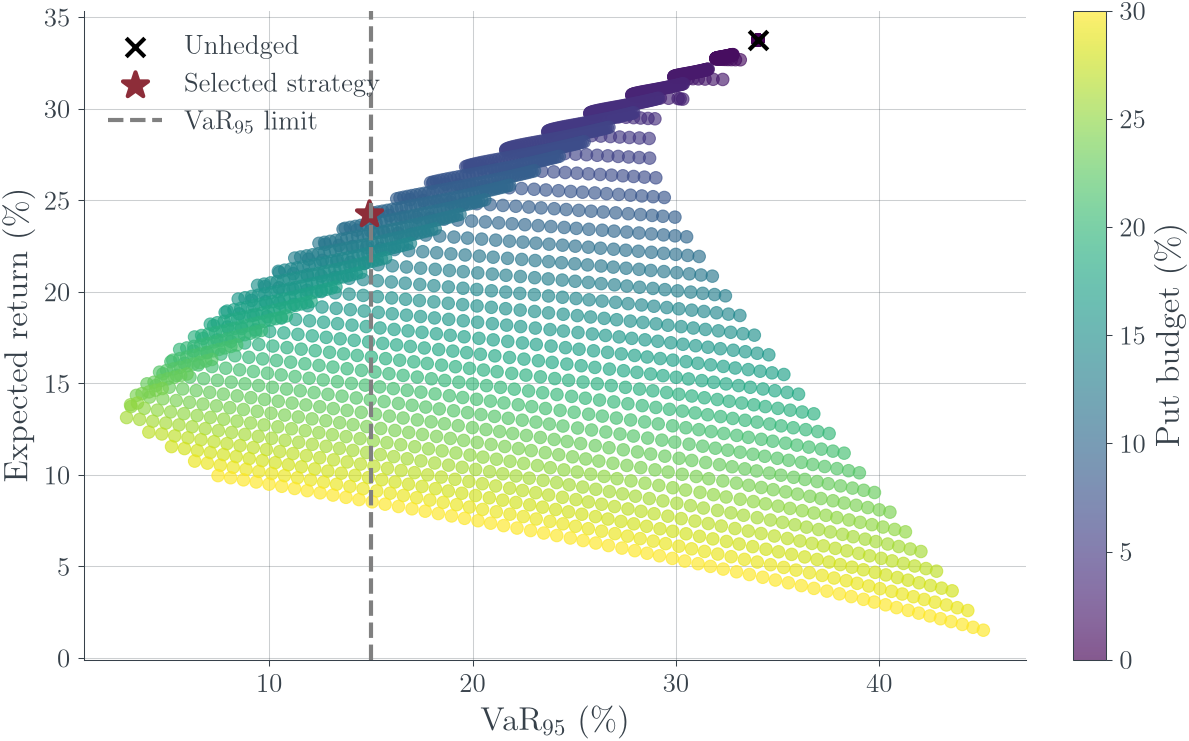

In [47]:
# Risk-return scatter with VaR constraint and selected strategy
fig, ax = plt.subplots(figsize=(8, 5), dpi=150, layout="constrained")

scatter = ax.scatter(
    insurance_df["VaR 95%"] * 100,
    insurance_df["E[R]"] * 100,
    c=insurance_df["put_budget_fraction"] * 100,
    alpha=0.65,
)

# Mark the unhedged portfolio
ax.scatter(
    summary_unhedged["VaR 95%"] * 100,
    summary_unhedged["E[R]"] * 100,
    marker="x",
    s=80,
    linewidths=2.0,
    color="black",
    label="Unhedged",
)

# Mark the selected VaR-constrained strategy
ax.scatter(
    best_var_strategy["VaR 95%"] * 100,
    best_var_strategy["E[R]"] * 100,
    marker="*",
    s=160,
    linewidths=2.0,
    color=rgb.tue_red,
    label="Selected strategy",
)

# VaR constraint
ax.axvline(
    VAR_LIMIT * 100,
    ls="--",
    lw=2,
    color="gray",
    label=r"VaR$_{95}$ limit",
)

cbar = plt.colorbar(scatter, ax=ax)
cbar.set_label(r"Put budget (\%)")

ax.set_xlabel(r"VaR$_{95}$ (\%)")
ax.set_ylabel(r"Expected return (\%)")

ax.grid(alpha=0.25)
ax.legend(loc="upper left", frameon=False)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.savefig(
    "figs/part3_var_constrained_strategy.pdf",
    bbox_inches="tight",
)

plt.show()

In [48]:
# Compact percentage table for reporting
selected_strategy_table = pd.DataFrame(
    {
        "Metric": [
            "Put budget",
            "Strike moneyness",
            "Expected return",
            "Volatility",
            "VaR95",
            "CVaR95",
            "Probability of loss",
        ],
        "Value": [
            f"{best_var_strategy['put_budget_fraction']:.0%}",
            f"{best_var_strategy['strike_moneyness']:.0%}",
            f"{best_var_strategy['E[R]']:.2%}",
            f"{best_var_strategy['Sigma']:.2%}",
            f"{best_var_strategy['VaR 95%']:.2%}",
            f"{best_var_strategy['CVaR 95%']:.2%}",
            f"{best_var_strategy['P(loss)']:.2%}",
        ],
    }
)

selected_strategy_table

,Metric,Value
0,Put budget,10%
1,Strike moneyness,95%
2,Expected return,24.27%
3,Volatility,44.15%
4,VaR95,14.91%
5,CVaR95,15.03%
6,Probability of loss,38.61%
